### Исследование объявлений о продаже квартир
В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

In [1]:
# ипортирую пакеты
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt 
import pylab as pl

Описание данных: 
* airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
* balcony — число балконов
* ceiling_height — высота потолков (м)
* cityCenters_nearest — расстояние до центра города (м)
* days_exposition — сколько дней было размещено объявление (от публикации до снятия)
* first_day_exposition — дата публикации
* floor — этаж
* floors_total — всего этажей в доме
* is_apartment — апартаменты (булев тип)
* kitchen_area — площадь кухни в квадратных метрах (м²)
* last_price — цена на момент снятия с публикации
* living_area — жилая площадь в квадратных метрах (м²)
* locality_name — название населённого пункта
* open_plan — свободная планировка (булев тип)
* parks_around3000 — число парков в радиусе 3 км
* parks_nearest — расстояние до ближайшего парка (м)
* ponds_around3000 — число водоёмов в радиусе 3 км
* ponds_nearest — расстояние до ближайшего водоёма (м)
* rooms — число комнат
* studio — квартира-студия (булев тип)
* total_area — общая площадь квартиры в квадратных метрах (м²)
* total_images — число фотографий квартиры в объявлении

In [2]:
try:
    data = pd.read_csv('C:/Users/USER/project 3/real_estate_data.csv', sep='\t')
except:
    data=pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
# Выведем общую информацию, по которой можно понять, в каких столбцах пропущены значения
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


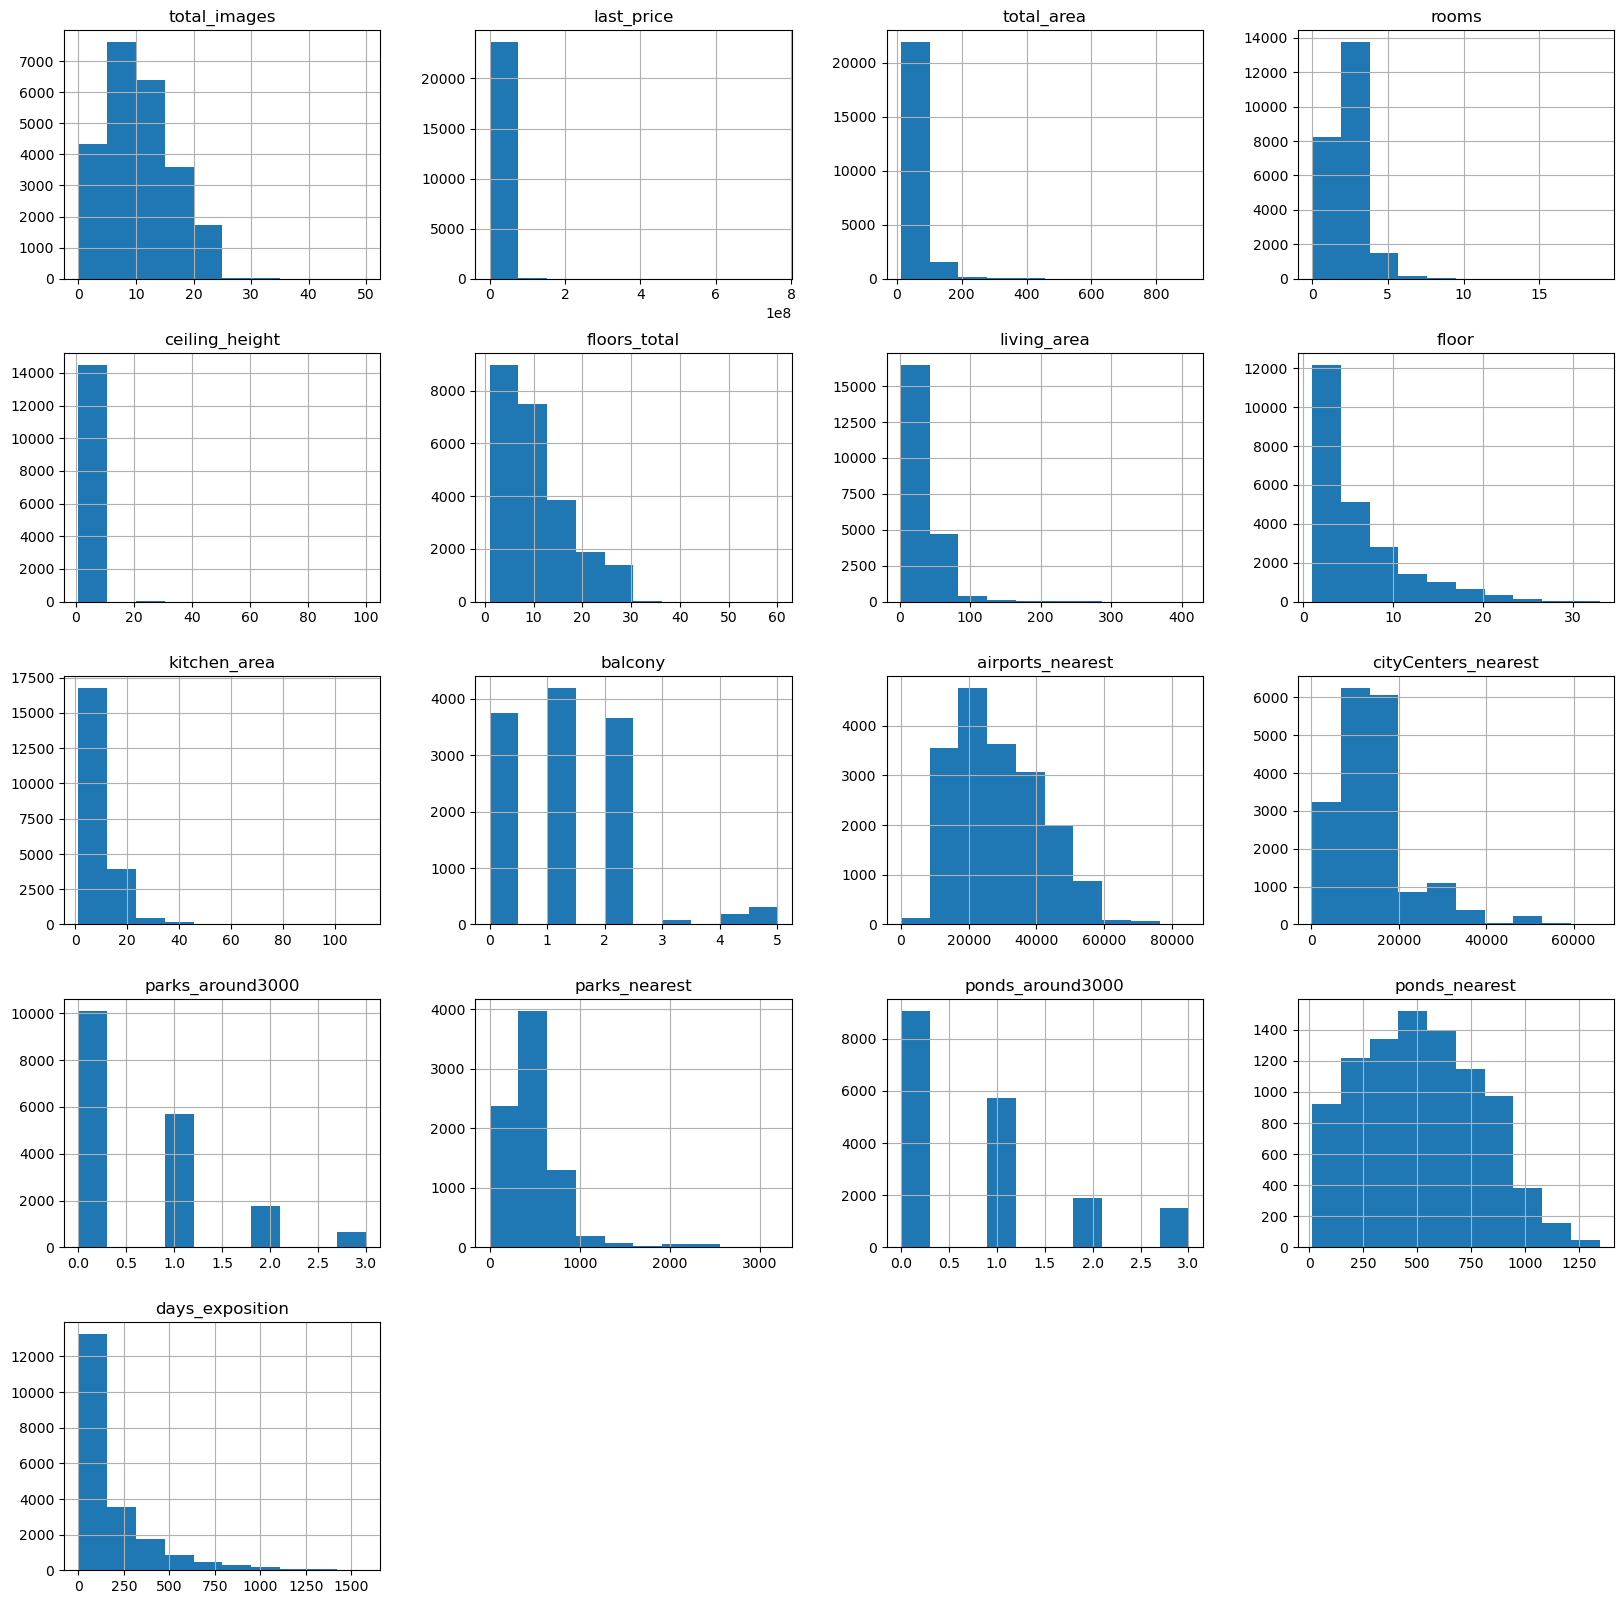

In [3]:
data.hist(figsize=(20, 20));

По первичной визуализации данных можно сделать следующие выводы:
* total_images — не видно аномалий;
* last_price — нужна отсечка сверху;
* total_area — нужна отсечка сверху;
* rooms — вероятно, все записи со значением больше определенного (4 или 5 ) нужно объединить в одну категорию; 
* ceiling_height — нужно исправление/очистка  данных;
* floors_total —  не видно аномалий;
* living_area — нужна отсечка сверху;
* floor  — не видно аномалий;
* kitchen_area — нужна отсечка сверху; 
* balcony — видны артефакты округления, нужно привести данные к целочисленным;
* airports_nearest — не видно аномалий;
* cityCenters_nearest — не видно аномалий;
* parks_around3000 —  не видно аномалий;
* parks_nearest —  не видно аномалий;
* ponds_around3000 —  не видно аномалий;
* ponds_nearest — не видно аномалий;
* days_exposition — не видно аномалий, возможно нужна отсечка сверху;


### Предобработка данных

In [4]:
#создание копии данных, чтобы в любой момент можно было сравить обработанные данные с исходными
prepared_data=data.copy()

#### Анализ и обработка пропущенных значений

Из общей информации о данных известно, в каких столбцах есть пропущенные значения:
1. высота потолков (ceiling_height);
1. жилая площадь (living_area);
1. апартаменты (is_apartment);
1. площадь кухни (kitchen_area);
1. балкон (balcony);
1. всего этажей (floors_total);
1. название населенного пункта (locality_name);
1. расстояние до аэропорта (airports_nearest);
1. расстояние до центра города (cityCenters_nearest);
1. парки в радиусе 3 км (parks_around3000);
1. расстояние до ближайшего парка (parks_nearest);
1. водоемы в радиусе 3 км (ponds_around3000);
1. расстояние до ближайшего водоема (ponds_nearest);
1. сколько дней было размещено объявление (days_exposition);

Проанализируем каждый из столбцов.

##### Анализ пропусков в данных о высоте потолков

In [5]:
#вывод уникальных значений высоты потолков 
print(data['ceiling_height'].sort_values().unique()) 


[  1.     1.2    1.75   2.     2.2    2.25   2.3    2.34   2.4    2.45
   2.46   2.47   2.48   2.49   2.5    2.51   2.52   2.53   2.54   2.55
   2.56   2.57   2.58   2.59   2.6    2.61   2.62   2.63   2.64   2.65
   2.66   2.67   2.68   2.69   2.7    2.71   2.72   2.73   2.74   2.75
   2.76   2.77   2.78   2.79   2.8    2.81   2.82   2.83   2.84   2.85
   2.86   2.87   2.88   2.89   2.9    2.91   2.92   2.93   2.94   2.95
   2.96   2.97   2.98   2.99   3.     3.01   3.02   3.03   3.04   3.05
   3.06   3.07   3.08   3.09   3.1    3.11   3.12   3.13   3.14   3.15
   3.16   3.17   3.18   3.2    3.21   3.22   3.23   3.24   3.25   3.26
   3.27   3.28   3.29   3.3    3.31   3.32   3.33   3.34   3.35   3.36
   3.37   3.38   3.39   3.4    3.42   3.43   3.44   3.45   3.46   3.47
   3.48   3.49   3.5    3.51   3.52   3.53   3.54   3.55   3.56   3.57
   3.58   3.59   3.6    3.62   3.63   3.65   3.66   3.67   3.68   3.69
   3.7    3.75   3.76   3.78   3.8    3.82   3.83   3.84   3.85   3.86
   3.8

In [6]:
print(prepared_data['ceiling_height'].median())
#заполним пропуски медианным значением 
prepared_data['ceiling_height']=prepared_data['ceiling_height'].fillna(prepared_data['ceiling_height'].median())
prepared_data['ceiling_height'].isna().sum()

2.65


0

#####  Анализ пропусков в данных о жилой площади

In [7]:
info_living_area=data[['living_area','total_area','kitchen_area','rooms','studio','is_apartment','open_plan','balcony']]
display(info_living_area)
#посчитаем сколько квартир каждого типа по количеству комнат
print('Всего квартир по количеству комнат:\n',info_living_area['rooms'].value_counts())


,living_area,total_area,kitchen_area,rooms,studio,is_apartment,open_plan,balcony
0,51.0,108.00,25.00,3,False,NaN,False,NaN
1,18.6,40.40,11.00,1,False,NaN,False,2.0
2,34.3,56.00,8.30,2,False,NaN,False,0.0
3,NaN,159.00,NaN,3,False,NaN,False,0.0
4,32.0,100.00,41.00,2,False,NaN,False,NaN
...,...,...,...,...,...,...,...,...
23694,73.3,133.81,13.83,3,False,NaN,False,NaN
23695,38.0,59.00,8.50,3,False,NaN,False,NaN
23696,29.7,56.70,NaN,2,False,NaN,False,NaN
23697,NaN,76.75,23.30,2,False,NaN,False,2.0


Всего квартир по количеству комнат:
 rooms
1     8047
2     7940
3     5814
4     1180
5      326
0      197
6      105
7       59
8       12
9        8
10       3
11       2
14       2
15       1
19       1
16       1
12       1
Name: count, dtype: int64


In [8]:
#посмотрим на 0 комнат -- логично предположить что это либо студии, либо открытые планировки
print('Всего студий и квартир с открытой планировкой по количеству комнат:\n', 
      info_living_area[info_living_area['studio']| info_living_area['open_plan']]['rooms'].value_counts())

print(info_living_area[~info_living_area['studio']&~info_living_area['open_plan']]['rooms'].value_counts())
print('Всего студий по количеству комнат:\n',
      info_living_area[info_living_area['studio']]['rooms'].value_counts())

print('Всего квартир с открытой планировкой по количеству комнат:\n',
      info_living_area[info_living_area['open_plan']]['rooms'].value_counts())

Всего студий и квартир с открытой планировкой по количеству комнат:
 rooms
0    197
1     14
3      2
2      1
5      1
4      1
Name: count, dtype: int64
rooms
1     8033
2     7939
3     5812
4     1179
5      325
6      105
7       59
8       12
9        8
10       3
11       2
14       2
15       1
19       1
16       1
12       1
Name: count, dtype: int64
Всего студий по количеству комнат:
 rooms
0    138
1     11
Name: count, dtype: int64
Всего квартир с открытой планировкой по количеству комнат:
 rooms
0    59
1     3
3     2
2     1
5     1
4     1
Name: count, dtype: int64


Действительно, 0 комнат только у квартир-студий и квартир с открытой планировкой.
Но также у некоторых студий отмечена одна комната, вероятно, это ошибка совершенная пользователями.

Обнулим количество комнат у квартир-студий.

In [9]:
#занулили количество комнат у студий
prepared_data.loc[prepared_data['studio'],'rooms']=0
prepared_data[prepared_data['studio']]['rooms'].value_counts()

rooms
0    149
Name: count, dtype: int64

Очевидно, жилая площадь и количество комнат в квартире связаны, и, в среднем, чем больше комнат &ndash; тем больше жилая площадь.
Поэтому, прежде чем заполнять пропуски в жилой площади, разобьем все  квартиры на категории по количеству комнат/типу планировки:
* однокомнатные:
* двухкомнатные;
* трехкомнатные;
* четырехкомнатные;
* пяти- и более комнатные квартиры объединим в одну категорию;
* квартиры-студии;
* квартиры с открытой планировкой (без комнат);
* ~~квартиры с открытой планировкой (с комнатами);~~

Заполнить медианным значением нельзя, так как в некоторых случаях это приведет к тому что жилая площадь окажется больше общей. Поэтому рассмотрим отношение жилая/общая и заполним медианой его ( по категории “Количество комнат”).

In [10]:
# категоризовали квартиры по количеству комнат
prepared_data['category']=prepared_data['rooms']
prepared_data['category']=prepared_data['category'].where(prepared_data['rooms']<5,'5+')
prepared_data.loc[prepared_data['studio'],'category']='studio'
prepared_data.loc[prepared_data['open_plan'],'category']='open'
# сразу удалим, их всего 8, а что это такое непонятно
open_with_rooms = prepared_data.query('open_plan and rooms>0').index
prepared_data = prepared_data.drop(open_with_rooms)

In [11]:
# завели колонку с отношением жилая/общая
prepared_data['living_area_to_total']=prepared_data['living_area']/prepared_data['total_area']
# заполнили ее медианными значениями (по категории 'количество комнат')
for cat in prepared_data['category'].unique():
    prepared_data.loc[(prepared_data['category'] == cat) & prepared_data['living_area'].isna(), 'living_area_to_total'] = \
    (prepared_data.loc[(prepared_data['category'] == cat), 'living_area_to_total']).median()
    
# восстановили пропущенные значения living_area, перемножив living_area_to_total на total
prepared_data['living_area']=\
prepared_data['living_area'].fillna(prepared_data['living_area_to_total']*prepared_data['total_area']).round(2)

print((prepared_data['living_area'].isna().sum()))
# вывели таблицу чтобы посмореть
prepared_data.head(10)

0


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category,living_area_to_total
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,3,0.472222
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.65,11.0,18.60,1,NaN,...,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,1,0.460396
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.65,5.0,34.30,4,NaN,...,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,2,0.612500
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,2.65,14.0,100.43,9,NaN,...,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,3,0.631658
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,2,0.320000
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.65,12.0,14.40,5,NaN,...,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0,1,0.473684
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,2.65,26.0,10.60,6,NaN,...,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,1,0.284182
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,2.65,24.0,41.89,22,NaN,...,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,2,0.585009
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.65,27.0,15.43,26,NaN,...,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0,1,0.465320
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,3,0.714754


##### Анализ пропусков в данных об апартаментах

In [12]:
#is_apartment -- заполнили пустые значения False, так как ноль ставят как значение по умолчанию
print(prepared_data['is_apartment'].value_counts())
prepared_data['is_apartment']=prepared_data['is_apartment'].fillna(False)
prepared_data['is_apartment'].value_counts()

is_apartment
False    2719
True       50
Name: count, dtype: int64


is_apartment
False    23641
True        50
Name: count, dtype: int64

##### Анализ пропусков  в данных о площади кухни

Заполним пропуски аналогично тому как заполнили пропуски в данных о жилой площади.

In [13]:
# посмотрим на площадь кухни у квартр с открытой планировкой и студий
print(info_living_area.query('studio or open_plan').count())
display(info_living_area.query('(studio or open_plan) and kitchen_area.isna()'))
# посмотрим на квартиры с площадью кухни = 0
display(info_living_area.query('kitchen_area==0'))

living_area     201
total_area      216
kitchen_area      0
rooms           216
studio          216
is_apartment     22
open_plan       216
balcony         145
dtype: int64


,living_area,total_area,kitchen_area,rooms,studio,is_apartment,open_plan,balcony
144,15.50,27.00,NaN,0,True,NaN,False,2.0
349,17.00,25.00,NaN,0,False,NaN,True,0.0
440,24.75,27.11,NaN,0,True,NaN,False,2.0
508,24.30,34.40,NaN,0,False,NaN,True,1.0
608,NaN,25.00,NaN,0,True,NaN,False,NaN
...,...,...,...,...,...,...,...,...
23210,18.00,26.00,NaN,0,True,NaN,False,0.0
23442,18.00,27.70,NaN,0,False,NaN,True,2.0
23554,NaN,26.00,NaN,0,True,NaN,False,NaN
23592,18.00,29.00,NaN,0,False,NaN,True,2.0


,living_area,total_area,kitchen_area,rooms,studio,is_apartment,open_plan,balcony


In [14]:
#заполнила нулями площадь кухни квартир-студий и квартир с открытой планировкой
prepared_data.loc[prepared_data['studio']|prepared_data['open_plan'],'kitchen_area']=0
#Завела колонку с отношением кухня/общая
prepared_data['kitchen_area_to_total']=prepared_data['kitchen_area']/prepared_data['total_area']
#заполнила ее медианными значениями (по категории 'количество комнат')
for cat in prepared_data['category'].unique():
    prepared_data.loc[(prepared_data['category'] == cat) & prepared_data['kitchen_area'].isna(), 'kitchen_area_to_total'] = \
    (prepared_data.loc[(prepared_data['category'] == cat), 'kitchen_area_to_total']).median()
#Восстановила пропущенные значаения living_area, перемножив living_area_to_total на total
prepared_data['kitchen_area']=\
prepared_data['kitchen_area'].fillna(prepared_data['kitchen_area_to_total']*prepared_data['total_area']).round(2)
prepared_data['kitchen_area'].isna().sum()
prepared_data
info1=prepared_data[['category','kitchen_area','kitchen_area_to_total','rooms']]
info1.sort_values(by='rooms')


,category,kitchen_area,kitchen_area_to_total,rooms
15606,studio,0.0,0.000000,0
22877,studio,0.0,0.000000,0
11051,open,0.0,0.000000,0
1528,studio,0.0,0.000000,0
5074,studio,0.0,0.000000,0
...,...,...,...,...
866,5+,16.6,0.045730,14
20829,5+,25.9,0.105542,14
5358,5+,100.0,0.169492,15
18848,5+,13.0,0.048148,16


##### Анализ пропущенных значений в данных о балконах

In [15]:
#balcony--пустые значения заполним нулями
prepared_data['balcony']=prepared_data['balcony'].fillna(0)
prepared_data['balcony'].value_counts()

balcony
0.0    15273
1.0     4193
2.0     3657
5.0      304
4.0      183
3.0       81
Name: count, dtype: int64

##### Анализ пропущенных значений в данных о количестве этажей в доме

In [16]:
print(prepared_data['floors_total'].median())
#посчитаем, как распределены пропуски в данных о количестве этажей в доме по расположению квартиры в доме
prepared_data[prepared_data['floors_total'].isna()]['floor'].value_counts()
# Я предполагала, что большинство пропусков будет в случае расположения квартиры на 1 этаже. 
#Тогда бы это говорило о том, что скорй всего в доме всего 1 этаж.
# это предположение не оправдалось.


9.0


floor
4     10
6      9
8      8
12     6
9      5
21     4
5      4
7      4
3      4
19     3
11     3
13     3
1      3
18     3
15     3
10     3
24     2
2      2
20     2
14     2
22     1
17     1
23     1
Name: count, dtype: int64

Так как в дальнейшем исследовании нас больше интересует тип расположения квартиры, нежели высота дома, то целесообразнее будет при категоризации отнести квартиры с пропущенными значениями высоты дома к типу “другой”, а не заполнять пропуски/удалять данные. 

##### Анализ пропусков и обработка неявных дубликатов в данных о названии насленных пунктов 

In [17]:
#заменим ё на e
prepared_data['locality_name']=prepared_data['locality_name'].str.replace('ё','е')
#удалим лишнее из названий
replace_list=['городской поселок ',
'деревня ',
'коттеджный поселок ',
'поселок городского типа имени ',
'поселок городского типа ',
'поселок станции ',
'поселок при железнодорожной станции ',
'поселок ',   
'садоводческое некоммерческое товарищество ',
'садовое товарищество ',
'село ']
for name in replace_list:
    prepared_data['locality_name']=prepared_data['locality_name'].str.replace(name,'')
print(len(prepared_data['locality_name'].unique()))
prepared_data.duplicated().sum()
#prepared_data.info()

306


0

In [18]:
# всего строчек, в которых не указан населенный пункт
print(prepared_data.query('locality_name.isna()')['total_images'].count())
# удалим строчки, в которых не указан населенный пункт
prepared_data=prepared_data.dropna(subset =['locality_name'] )


49


Восстановить название населенных пунктов без запроса дополнительной информации достаточно трудоемко. Так как таких строчек крайне мало – удалим эти данные.

##### Анализ пропусков в данных о расстоянии до центра города и аэропорта

In [19]:
# выводим данные о локациях, ни в одной из записей из которых не заполнена соответствующая колонка
def locations_with_total_missing(df, col):
    df['present'] = df[col].notna()
    info_locality=df.pivot_table(index='locality_name', values='present', aggfunc=["sum","count"])
    res=info_locality[info_locality[('sum','present')]==0].sort_values(by=('count','present'),ascending=False).head(60)
    return res

print(locations_with_total_missing(prepared_data,'airports_nearest' ).head(10))
print(locations_with_total_missing(prepared_data,'cityCenters_nearest' ).head(10))
# если потребуется анализировать расстояния для объявлений за пределами Санкт-Петербурга
#- эти данные придется вводить вручную,пока пропускаем

                    sum   count
                present present
locality_name                  
Кудрово               0     471
Всеволожск            0     398
Гатчина               0     307
Выборг                0     237
Новое Девяткино       0     144
Сертолово             0     142
Кириши                0     125
Бугры                 0     114
Сланцы                0     112
Волхов                0     111
                    sum   count
                present present
locality_name                  
Кудрово               0     471
Всеволожск            0     398
Гатчина               0     307
Выборг                0     237
Новое Девяткино       0     144
Сертолово             0     142
Кириши                0     125
Бугры                 0     114
Сланцы                0     112
Волхов                0     111


Достоверно восстановить расстояние до центра города и до ближайшего аэропорта самостоятельно затруднительно. 

При необходимости возможно измерить расстояние от населенных пунктов в области до аэропорта можно вручную по карте, так как в Санкт-Петербурге и Ленинградской области всего один действующий аэропорт – аэропорт Пулково. 
Но такая обработка данных не представляется целесообразной, поэтому при необходимости лучше обратиться к геосервисам с просьбой предоставить более полные данные.

Аналогичная ситуация с расстоянием до центра города.  

In [20]:
#всего не указано расстояние до центра в Санкт-Петербурге
print(prepared_data[(prepared_data['locality_name']=='Санкт-Петербург')&(prepared_data['cityCenters_nearest'].isna())]
      ['total_images'].count())
# удалила строчки, где в Санкт-Петербурге не указано расстояние до центра, так как нужно будет анализировать эти данные позже
# предпочла удалить, а не заполнять медианным значением, так как таких строк немного,
#а заполнение медианными данными может внести шум
to_del=prepared_data.query('locality_name=="Санкт-Петербург" and cityCenters_nearest.isna()').index
prepared_data=prepared_data.drop(to_del)
prepared_data

61


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category,living_area_to_total,kitchen_area_to_total,present
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,False,...,16028.0,1.0,482.0,2.0,755.0,NaN,3,0.472222,0.231481,True
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.65,11.0,18.60,1,False,...,18603.0,0.0,NaN,0.0,NaN,81.0,1,0.460396,0.272277,True
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.65,5.0,34.30,4,False,...,13933.0,1.0,90.0,2.0,574.0,558.0,2,0.612500,0.148214,True
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,2.65,14.0,100.43,9,False,...,6800.0,2.0,84.0,3.0,234.0,424.0,3,0.631658,0.128571,True
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,False,...,8098.0,2.0,112.0,1.0,48.0,121.0,2,0.320000,0.410000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.30,3,False,...,4232.0,1.0,796.0,3.0,381.0,NaN,3,0.547792,0.103356,True
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,2.65,5.0,38.00,4,False,...,NaN,NaN,NaN,NaN,NaN,45.0,3,0.644068,0.144068,False
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,2.65,3.0,29.70,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0.523810,0.161075,False
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,44.90,12,False,...,10364.0,2.0,173.0,3.0,196.0,602.0,2,0.585009,0.303583,True


In [21]:
# не указано расстояние до аэропорта в Санкт-Петербурге
print(prepared_data[(prepared_data['locality_name']=='Санкт-Петербург')&(prepared_data['airports_nearest'].isna())]
      ['total_images'].count())

24


##### Анализ пропусков в данных о расттоянии до ближайшего парка и количестве парков в радиусе 3 км

In [22]:
info_obj_2=prepared_data[['locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest']]
info_obj_2

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0
1,Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN
2,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0
3,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0
4,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0
...,...,...,...,...,...,...,...
23694,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0
23695,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
23696,Рождествено,NaN,NaN,NaN,NaN,NaN,NaN
23697,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0


In [23]:
# посмотрим есть ли строчки, в которых не указано количество парков в радиусе 3 км,
#но при этом указано расстояние до ближайшего парка
display(info_obj_2[info_obj_2['parks_around3000'].isna() & info_obj_2['parks_nearest'].notna()])
# таких строчек нет


,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest


In [24]:
# посмотрим есть ли строчки, в которых указано количество парков в радиусе 3 км,
#но при этом не указано расстояние до ближайшего парка

display(info_obj_2[info_obj_2['parks_around3000'].notna() & info_obj_2['parks_nearest'].isna()]
        .sort_values(by='parks_around3000',ascending=False))
# Такие строчки есть, но при этом число парков в радиусе 3 км равно 0

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
1,Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN
15604,Санкт-Петербург,32605.0,13704.0,0.0,NaN,1.0,580.0
15589,Санкт-Петербург,37652.0,10124.0,0.0,NaN,0.0,NaN
15590,Санкт-Петербург,23344.0,2885.0,0.0,NaN,0.0,NaN
15593,Сестрорецк,56343.0,33272.0,0.0,NaN,1.0,545.0
...,...,...,...,...,...,...,...
7821,Санкт-Петербург,34967.0,14640.0,0.0,NaN,1.0,564.0
7822,Санкт-Петербург,13990.0,12786.0,0.0,NaN,0.0,NaN
7825,Санкт-Петербург,13849.0,12949.0,0.0,NaN,1.0,1130.0
7827,Санкт-Петербург,15598.0,10436.0,0.0,NaN,1.0,663.0


In [25]:
#посмотрим, есть ли строчки в которых пропущены значения в обоих столбцах про парки
display(info_obj_2[info_obj_2['parks_around3000'].isna() & info_obj_2['parks_nearest'].isna()])
# для таких данных заполним пропуски в данных о количестве парков в радиусе 3 км нулями
prepared_data.loc[(prepared_data['parks_around3000'].isna() & prepared_data['parks_nearest'].isna()),'parks_around3000']=0
#проверим, остались ли пустые значения в данных о количестве парков в радиусе 3 км 
display(prepared_data.loc[prepared_data['parks_around3000'].isna()])


,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
5,Янино-1,NaN,NaN,NaN,NaN,NaN,NaN
8,Мурино,NaN,NaN,NaN,NaN,NaN,NaN
12,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN
22,Кудрово,NaN,NaN,NaN,NaN,NaN,NaN
30,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
23683,Дзержинского,NaN,NaN,NaN,NaN,NaN,NaN
23692,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN
23695,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
23696,Рождествено,NaN,NaN,NaN,NaN,NaN,NaN


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category,living_area_to_total,kitchen_area_to_total,present


In [26]:
# посмотрим, какое максимальное расстояние указано до ближайшего парка
info_obj_2.sort_values(by='parks_nearest',ascending=False)

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
10959,Санкт-Петербург,14821.0,9734.0,0.0,3190.0,1.0,431.0
19430,Санкт-Петербург,14821.0,9734.0,0.0,3190.0,1.0,431.0
1590,Санкт-Петербург,14878.0,9791.0,0.0,3064.0,1.0,264.0
19208,Санкт-Петербург,36805.0,8656.0,0.0,3013.0,3.0,537.0
23080,Санкт-Петербург,14965.0,9877.0,1.0,2984.0,1.0,284.0
...,...,...,...,...,...,...,...
23691,Санкт-Петербург,19424.0,4489.0,0.0,NaN,1.0,806.0
23692,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN
23695,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
23696,Рождествено,NaN,NaN,NaN,NaN,NaN,NaN


Заполнять нулями пропущенные значения в данных о расстоянии до ближайшего парка нельзя (иначе получится что  парк под окнами). 
Заполнение медианным значением тоже кажется неправдоподобным, так как максимально указанное расстояние до парка составляет немногим более 3 км.

Возможно, геосервисы считают ближайшим парком только парки расположенные в радиусе 3200 м, и если парки в такой области отсутствуют, то данные заполняются пустыми значениями.

Для анализа влияния расстояния до парка на какие-либо факторы рекомендуется запросить более полную информацию у геосервисов.

##### Анализ пропусков в данных о расттоянии до ближайшего водоема и количестве водоемов в радиусе 3 км

In [27]:
# поступаем аналогично анализу пропусков в данных о парках
info_obj_2[info_obj_2['ponds_around3000'].isna() & info_obj_2['ponds_nearest'].notna()]

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest


In [28]:
info_obj_2[info_obj_2['ponds_around3000'].notna() & info_obj_2['ponds_nearest'].isna()]

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
1,Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN
6,Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN
7,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN
9,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN
11,Ломоносов,48252.0,51677.0,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...
23684,Санкт-Петербург,11827.0,11459.0,0.0,NaN,0.0,NaN
23685,Ломоносов,48393.0,51818.0,0.0,NaN,0.0,NaN
23687,Санкт-Петербург,40837.0,16704.0,0.0,NaN,0.0,NaN
23688,Санкт-Петербург,15632.0,14428.0,0.0,NaN,0.0,NaN


In [29]:
display(info_obj_2[(info_obj_2['ponds_around3000'].isna()) & info_obj_2['ponds_nearest'].isna()])
prepared_data.loc[(prepared_data['ponds_around3000'].isna() & prepared_data['ponds_nearest'].isna()),'ponds_around3000']=0
prepared_data.loc[prepared_data['ponds_around3000'].isna()]

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
5,Янино-1,NaN,NaN,NaN,NaN,NaN,NaN
8,Мурино,NaN,NaN,NaN,NaN,NaN,NaN
12,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN
22,Кудрово,NaN,NaN,NaN,NaN,NaN,NaN
30,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
23683,Дзержинского,NaN,NaN,NaN,NaN,NaN,NaN
23692,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN
23695,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
23696,Рождествено,NaN,NaN,NaN,NaN,NaN,NaN


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category,living_area_to_total,kitchen_area_to_total,present


In [30]:
# посмотрим, какое максимальное расстояние указано до ближайшего пруда
info_obj_2.sort_values(by='ponds_nearest',ascending=False)

,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
20726,Стрельна,28377.0,23562.0,1.0,1073.0,1.0,1344.0
19138,Стрельна,28317.0,23506.0,1.0,1069.0,1.0,1341.0
19924,Стрельна,28317.0,23506.0,1.0,1069.0,1.0,1341.0
1476,Санкт-Петербург,50988.0,16316.0,0.0,NaN,1.0,1337.0
12054,Санкт-Петербург,36488.0,9283.0,0.0,NaN,1.0,1313.0
...,...,...,...,...,...,...,...
23690,Санкт-Петербург,20151.0,6263.0,1.0,300.0,0.0,NaN
23692,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN
23695,Тосно,NaN,NaN,NaN,NaN,NaN,NaN
23696,Рождествено,NaN,NaN,NaN,NaN,NaN,NaN


Заполнять нулями пропущенные значения в данных о расстоянии до ближайшего пруда нельзя (иначе получится что лужа под окнами). Заполнение медианным значением тоже кажется неправдоподобным, так как максимально указанное расстояние до озера составляет немногим более 1 км.

Для анализа влияния расстояния до гидрологических объектов на какие-либо факторы рекомендуется запросить более полную информацию у геосервисов.

##### Анализ пропусков в данных о  сроке  размещения объявления

Пропущенные значения в даннах о сроке размещения означают, что квартира еще не продана. Вычислим, сколько квартир еще не продано.

In [31]:
not_sold_yet_count=prepared_data[prepared_data['days_exposition'].isna()].shape[0]
not_sold_yet=prepared_data[prepared_data['days_exposition'].isna()].shape[0]/prepared_data.shape[0]
print(f'Процент непроданных квартир:{ not_sold_yet:.2%},\nколичество:{not_sold_yet_count}')


Процент непроданных квартир:13.33%,
количество:3144


Непроданных квартир много, так что удалить их нельзя. Чтобы в дальнейшем было удоно разделять данные на проданные и непроданные квартиры, заведем дополнительный столбец.

In [32]:
prepared_data['sold_status']='sold'
prepared_data.loc[prepared_data['days_exposition'].isna(),'sold_status']='unsold'

##### Итог предобработки данных

In [33]:
# проверим, что с нулевыми значениями
print(prepared_data.info())
print(f'Удалили данных из исходной таблицы {((data.shape[0]-prepared_data.shape[0])/data.shape[0]):.2%}')

<class 'pandas.core.frame.DataFrame'>
Index: 23581 entries, 0 to 23698
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_images           23581 non-null  int64  
 1   last_price             23581 non-null  float64
 2   total_area             23581 non-null  float64
 3   first_day_exposition   23581 non-null  object 
 4   rooms                  23581 non-null  int64  
 5   ceiling_height         23581 non-null  float64
 6   floors_total           23497 non-null  float64
 7   living_area            23581 non-null  float64
 8   floor                  23581 non-null  int64  
 9   is_apartment           23581 non-null  bool   
 10  studio                 23581 non-null  bool   
 11  open_plan              23581 non-null  bool   
 12  kitchen_area           23581 non-null  float64
 13  balcony                23581 non-null  float64
 14  locality_name          23581 non-null  object 
 15  airport

Пропуски в столбцах:
* высота потолков;
* жилая площадь; 
* площадь кухни;
* количестве этажей в доме:
* количество балконов;
* апартаменты;

обусловлены человеческим фактором. Кто-то не знает, какая жилая площадь/высота потолков и т.д  в квартире, кто-то не захотел заполнять или не посчитал эту информацию полезной. 

Площадь кухни не указана отдельно в квартирах-студиях, квартирах с открытой планировкой или таких квартирах, где кухня объединена с комнатой.

Пропуски в данных о сроке размещения означают что объявление еще не снято с продажи.

В колонках с булевским или категориальным типом данных пропуски   могут быть обусловлены тем, что отмечают только наличе признака/категории, а в случае их отсутствия оставляют данные незаполненными 

В колонках с данными, полученными автоматически, пропуски могут быть обусловлены технической ошибкой при выгрузке или отсутствием информации в сервисе.

Также пропуски могут возникать из-за неполных данных/некорректного заполнения данных к которым обращается сам геосервис при формировании данных по запросу. 


#### Изменение типов данных

In [34]:
prepared_data['balcony']=prepared_data['balcony'].astype('int')
prepared_data['parks_around3000']=prepared_data['parks_around3000'].astype('int')
prepared_data['ponds_around3000']=prepared_data['ponds_around3000'].astype('int')
prepared_data['first_day_exposition'] = pd.to_datetime(prepared_data['first_day_exposition'])
#удалила лишние, технические столбцы
prepared_data=prepared_data.drop(columns=['living_area_to_total', 'kitchen_area_to_total','present'])
prepared_data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition', 'category', 'sold_status'],
      dtype='object')

Данные в столбцах ‘balcony’, ‘parks_around3000’ и ‘ponds_around3000’ переведены в целочисленный тип, так как эти данные могут принимать только целочисленные значения.

Не изменены значения  на целочисленный тип данных в столбце ‘floors_total’ так как в нем остались пропущенные значения. Это сделано намеренно, чтобы не искажать категоризацию по типу расположения квартиры в доме.

Столбец ‘first_day_exposition’  переведен в формат дата-время для удобства дальнейшего анализа.

### Добавление столбцов в таблицу

In [35]:
#добавила цену за метр
prepared_data['price_per_metr']=(prepared_data['last_price']/prepared_data['total_area']).round(2)
#для удобства добавила цену за метр в тысячах рублей
prepared_data['price_per_metr_thousand']=(prepared_data['price_per_metr']/1000).round(3)
#для удобства добавила полную цену в миллионах
prepared_data['last_price_mil']=(prepared_data['last_price']/1000000).round(6)
#день недели, в который опубликовали объявление 
prepared_data['weekday'] = prepared_data['first_day_exposition'].dt.weekday
#месяц публикации объявления
prepared_data['month']= prepared_data['first_day_exposition'].dt.month
#год публикации объявления
prepared_data['year']= prepared_data['first_day_exposition'].dt.year
# расстояние в километрах до центра города
prepared_data['city_centers_km']=(prepared_data['cityCenters_nearest']/1000).round(2)
# категоризация квартир по типу расположения в здании 
prepared_data['floor_type']='другой'
prepared_data['floor_type']=prepared_data['floor_type']\
.where((prepared_data['floor']!=prepared_data['floors_total']), 'последний')
prepared_data['floor_type']=prepared_data['floor_type'].where(prepared_data['floor']!=1, 'первый')


### Исследовательский анализ данных

#### Изучение параметров объектов и построение отдельныx гистограмм для каждого из этих параметров



##### Анализ  общей площади

In [36]:
# функция, выдающая основную информацию и ящик с усами
def plot_something(col):
    print(prepared_data[col].describe())
    boxplot = prepared_data.boxplot(column=[col], figsize=(10, 10));


In [37]:
# функция на удаление данных
def drop_where(data, query) :
    to_del=data.query(query).index
    return data.drop(to_del)

In [38]:
# построение диаграммы
def hist_info (data, col1,col2, lim1, lim2,list1, bins1, siz1, header, footer, describe_col1=False, val_count=False) :
    # сколько отсекли сверху
    a=len(data[(data[col1]<lim1)&(data[col2].isin(list1))])/data[data[col2].isin(list1)].shape[0]
    # сколько отсекли снизу
    b=len(data[(data[col1]>lim2)&(data[col2].isin(list1))])/data[data[col2].isin(list1)].shape[0]
    print(
f'''Отсекли всего снизу: {data[(data[col1]<lim1)&(data[col2].isin(list1))][col1].count()}, в процентах {a:.1%}
Отсекли всего сверxу:{data[(data[col1]>lim2)&(data[col2].isin(list1))][col1].count()}, в процентах {b:.1%}''')
    
    frame = data[(data[col1]>=lim1)&(data[col1]<=lim2)&(data[col2].isin(list1))];
    # гистограмма
    ax = frame.plot(y = col1, bins=bins1, figsize=(siz1, siz1), kind = 'hist',
                   title = header, legend=False, grid = True);
    ax.set_xlabel(footer)
    ax.set_ylabel("Количество объектов")
    # подсчет значений и основная информация
    if val_count==True:
        print(data[data[col2].isin(list1)][col1].value_counts())
    if describe_col1==True:
        print(data[data[col2].isin(list1)][col1].describe())

Так как в зависимости от задачи имеет смысл анализировать разные срезы данных, то имеет смысл удалять редкие и выбивающиеся значения по категориям.

count    23581.000000
mean        60.252841
std         35.492609
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64


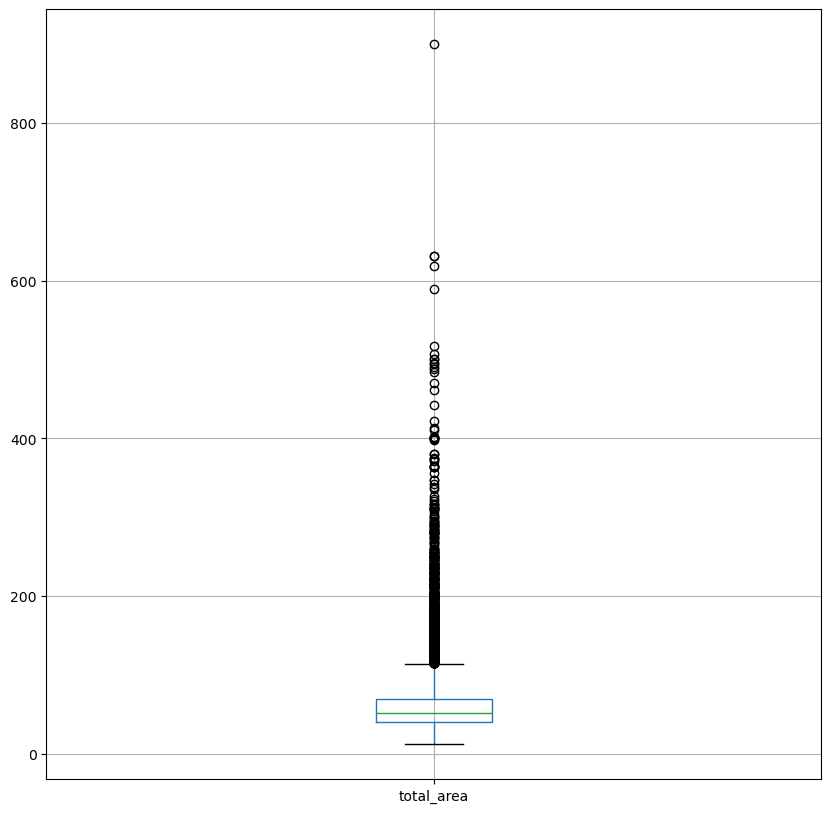

In [39]:
plot_something('total_area')

In [40]:
prepared_data.query('total_area>=112.5').shape[0]

1296

По ящику с усами видно, что за его пределы уходят только квартиры с большой площадью (более 112 метров). 
Но выкидывать все квартиры, площадью более 112 метров не верно, так как такие площади не являются аномалиями, а удаление большого количества данных исказит их.

Отсекли всего снизу: 0, в процентах 0.0%
Отсекли всего сверxу:225, в процентах 1.0%


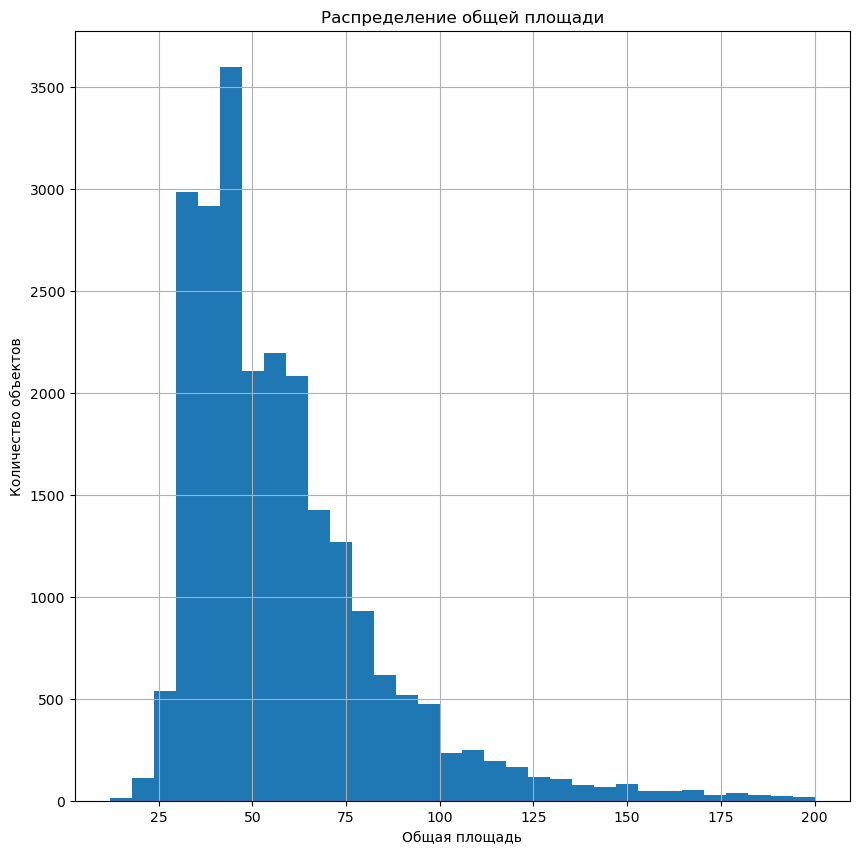

In [41]:
hist_info(prepared_data,'total_area','category',0,200,prepared_data['category'].unique(),32,10,
          'Распределение общей площади','Общая площадь')

На гистограмме распределения общей площади хорошо видны отдельные пики. Самый высокий –  45 м.
    
Также выделяются пики в районе 31 метра – однокомнатные квартиры, и 60 метров – трехкомнатные квартиры. 

Стоит проанализировать распределение общей площади по отдельности для каждой категории.
Очевидно, что для каждой категории будут свои хвосты, поэтому и отсечки для каждой категории будут свои.

In [42]:
# сводная таблица по категории квартиры
display(prepared_data.pivot_table(index='category',values='total_area', aggfunc=["count",'mean','median','min', 'max']))

,count,mean,median,min,max
,total_area,total_area,total_area,total_area,total_area
category,,,,,
1,8001,37.622770,36.600,12.0,494.1
2,7905,55.804635,53.000,20.0,196.0
3,5780,77.653611,72.875,40.1,363.1
4,1173,107.716027,99.600,42.0,500.0
5+,514,189.510973,165.000,40.0,900.0
open,59,32.707288,26.100,16.0,371.0
studio,149,27.783154,26.000,15.5,98.4


Отсекли всего снизу: 0, в процентах 0.0%
Отсекли всего сверxу:34, в процентах 0.4%


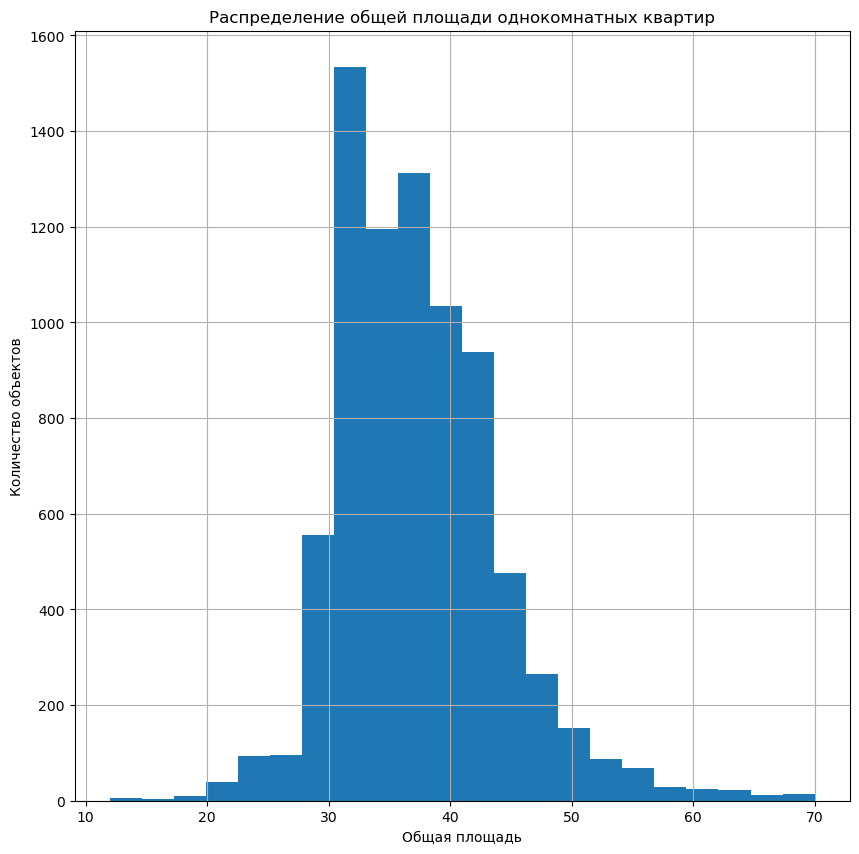

In [43]:
hist_info(prepared_data,'total_area','category',0,70,[1],22,10,
          'Распределение общей площади однокомнатных квартир', 'Общая площадь')

На гистограмме распределения общей площади однокомнатных квартир выделяется два пика: первый в районе 31-33  кв. метрови второй в районе 36-38 кв. метров
Вероятно, что первый пик это квартиры из старого фонда (‘хрущевки’), а второй пик – новостройки.

При анализе однокомнатных квартир следует исключать квартиры площадью более 70 кв. метров.

Отсекли всего снизу: 6, в процентах 0.1%
Отсекли всего сверxу:13, в процентах 0.2%
count    7905.000000
mean       55.804635
std        13.112140
min        20.000000
25%        46.000000
50%        53.000000
75%        62.000000
max       196.000000
Name: total_area, dtype: float64


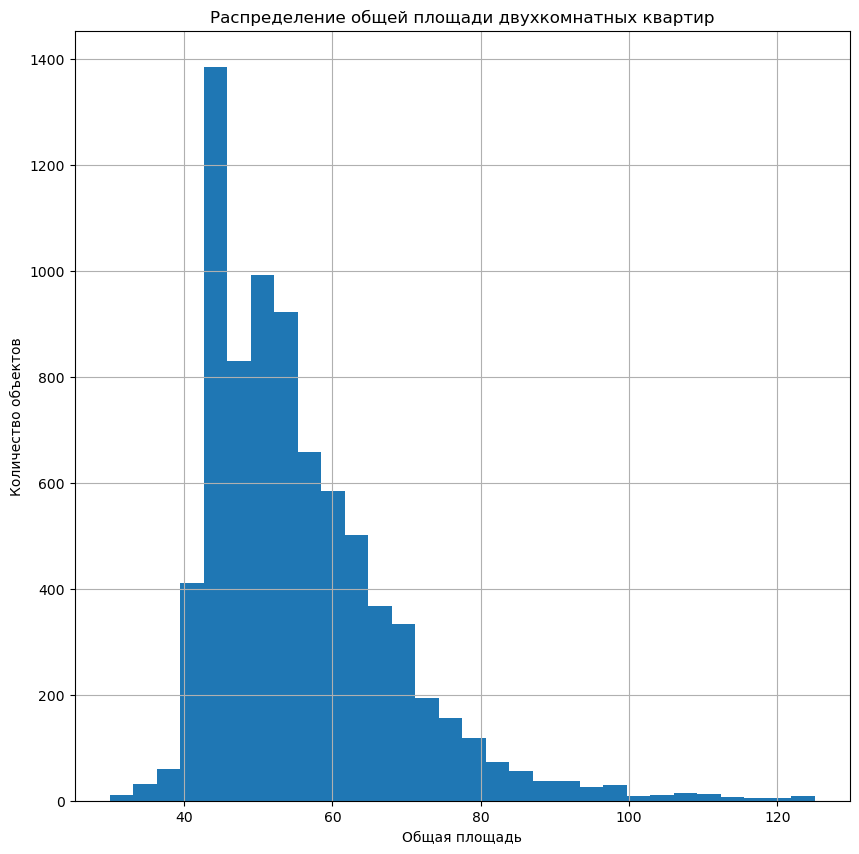

In [44]:

hist_info(prepared_data,'total_area','category',30,125,[2],30,10,
          'Распределение общей площади двухкомнатных квартир','Общая площадь',
          describe_col1=True)

На гистограмме распределения общей площади двухкомнатных квартир выделяются два пика: первый в районе 46-49  кв. метров и второй в районе 55-59 кв. метров
Вероятно, что первый пик это квартиры из старого фонда (‘хрущевки’), а второй пик – новостройки.

При анализе двухкомнатных квартир следует исключать квартиры площадью более 125 кв. метров и менее 30 кв. метров.


Отсекли всего снизу: 72, в процентах 1.2%
Отсекли всего сверxу:38, в процентах 0.7%


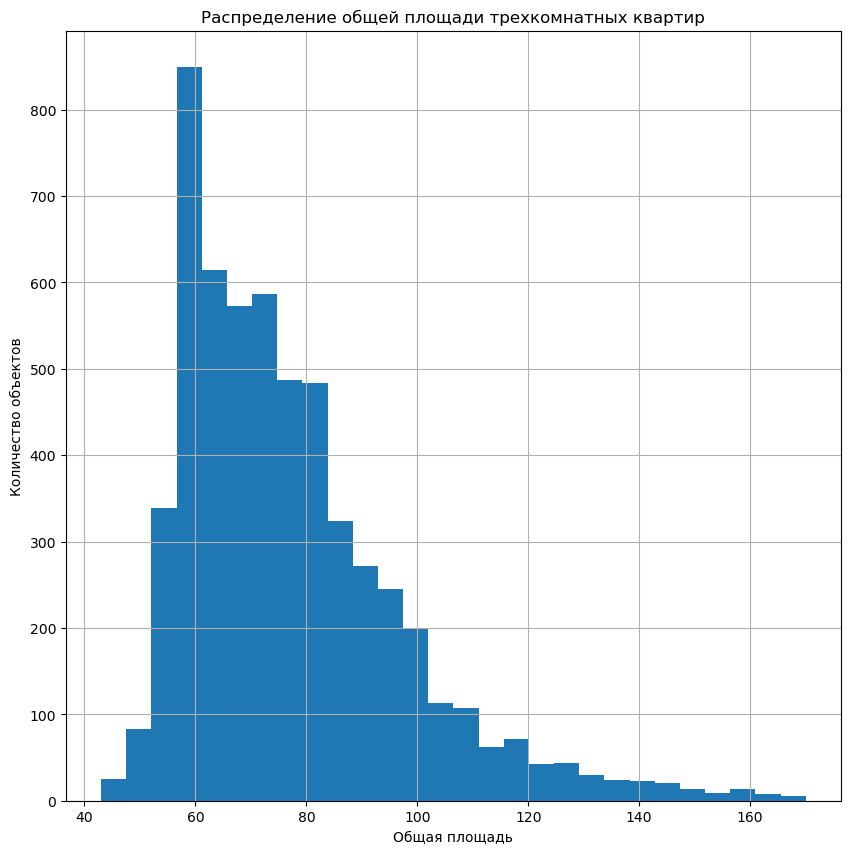

In [45]:
hist_info(prepared_data,'total_area','category',43,170,[3],28,10,
         'Распределение общей площади трехкомнатных квартир','Общая площадь')

В отличие от одно- и двух-комнатных квартир явного второго пика не наблюдается, но вместо этого можно увидеть некоторое плато.
По всей видимости, пик по-прежнему относится к советским нормам(58-61 кв.м.), а площади трехкомнатных квартир в современных домах распределены почти равномерно в достаточно широких пределах(60-80 кв.м.)

In [46]:
prepared_data = drop_where(prepared_data,'category == 3 and (total_area>170 or total_area<42)')

Отсекли всего снизу: 2, в процентах 0.2%
Отсекли всего сверxу:7, в процентах 0.6%


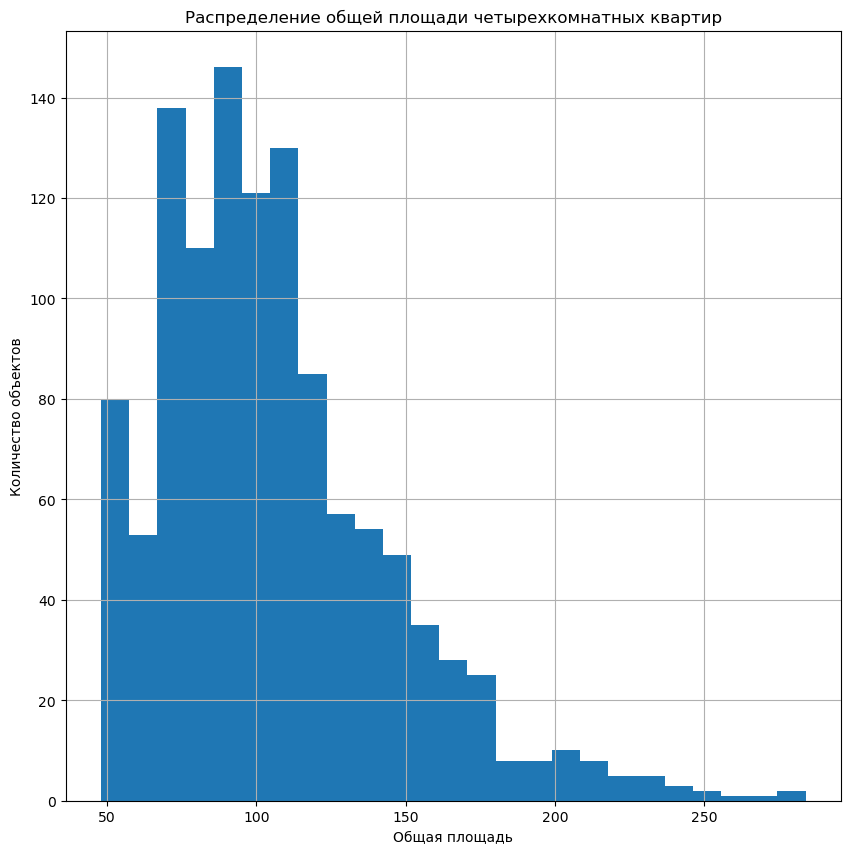

In [47]:
hist_info(prepared_data,'total_area','category',45,290,[4],25,10,
         'Распределение общей площади четырехкомнатных квартир','Общая площадь')

Про четырехкомнатные квартиры сложно что-то сказать. В четырехкомнатные квартиры попадают как дореволюционные квартиры, так и перепланировки из трехкомнатных или пятикомнатных. Также в новостройках четырехкомнатных квартир немного, и их общая площадь сильно отличается.
Можно предположить, что самый левый пик это перепланировки из трехкомнатных квартир, а остальные – квартиры в домах относительно типовой постройки. 

При анализе стоит исключить очень маленькие (меньше 45) четырехкомнатные квартиры и очень большие (больше 280).


Отсекли всего снизу: 2, в процентах 0.4%
Отсекли всего сверxу:5, в процентах 1.0%


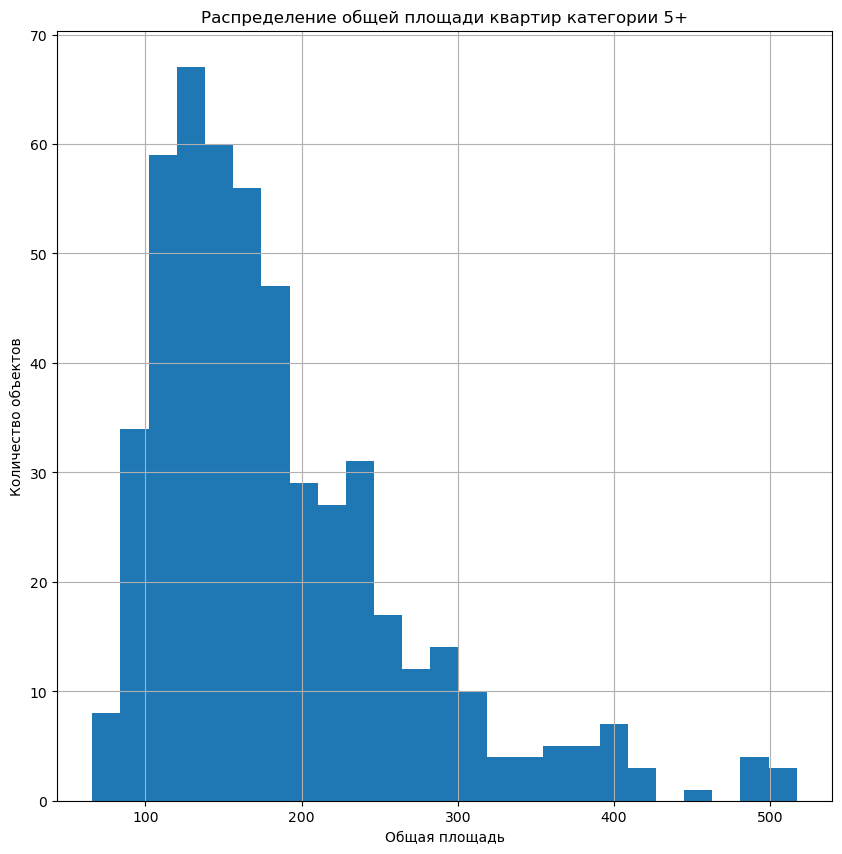

In [48]:
hist_info(prepared_data,'total_area','category',65,550,['5+'],25,10,
          'Распределение общей площади квартир категории 5+','Общая площадь')

Квартиры с 5 и более команатмии распределены унимодально, с пиком в районе 150 кв. метров.

Отсекли всего снизу: 0, в процентах 0.0%
Отсекли всего сверxу:5, в процентах 2.4%


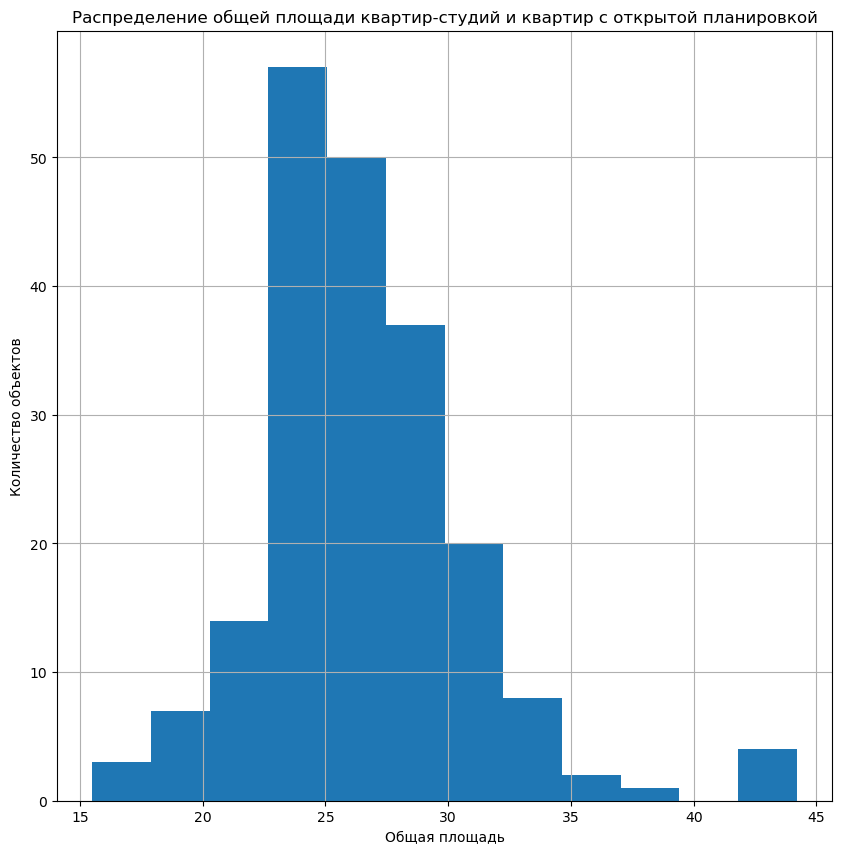

In [49]:
# объединим квартиры-студии и квартиры с открытой планировкой, так как их медианные площади равны, а средние -- близки
hist_info(prepared_data,'total_area','category',15,45,['studio', 'open'],12,10,
         'Распределение общей площади квартир-студий и квартир с открытой планировкой','Общая площадь')


При анализе площади имеет смысл объединить категории 'studio' и 'open', так как по сводной таблице видно, что их медианные площади равны, а средние -- близки.

Явно выражен один пик -- квартиры площадью 22.5-25 кв.м

В целом, выборка небольшая, поэтому делать какие-либо статистические выводы затруднительно.

##### Таблица  граничных значений общей площади

Составим таблицу граничных значений, на которую будем ориентироваться при дальнейшем анализе влияния общей площади: 



|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные| $0\, м^2$       | $70\, м^2$       |
| Двухкомнатные | $30\, м^2$       | $125\, м^2$       |
| Трехкомнатные | $42\, м^2$      | $170\, м^2$  |
| Четырехкомнатные |$45\, м^2$       | $280\, м^2$       |
| 5+ | $65\, м^2$       | $550\, м^2$       |
|студии/open | $0\,(15)\,м^2$     | $45\, м^2$    |


##### Удаление аномальных значений общей площади по категориям



In [ ]:
prepared_data = drop_where(prepared_data,'category == 1 and total_area>70')
prepared_data = drop_where(prepared_data,'category == 2 and (total_area<30 or total_area>125)')
prepared_data = drop_where(prepared_data,'category == 3 and (total_area<42 or total_area>170 )')
prepared_data = drop_where(prepared_data,'category == 4 and (total_area<45 or total_area>280 )')
prepared_data = drop_where(prepared_data,'category == "5+" and (total_area<65 or total_area>550 )')
prepared_data = drop_where(prepared_data,'(category == "studio" or category == "open" )and (total_area<0 or total_area>45 )')

#Еще раз построим гистограмму 
hist_info(prepared_data,'total_area','category',0,550,prepared_data['category'].unique(),32,10,
         'Распределение общей площади','Общая площадь')

In [ ]:
# сводная таблица по категории квартиры после чистки
display(prepared_data.pivot_table(index='category',values='total_area', aggfunc=["count",'mean','median','min', 'max']))

##### Анализ жилой площади


In [ ]:
plot_something('living_area')

In [ ]:
prepared_data.query('living_area>=77.4').shape[0]

По ящику с усами видно, что за его пределы уходят только квартиры с большой жилой площадью (более 77 метров). 
Но выкидывать все квартиры, с жилой площадью более 72 метров не верно, так как такие площади не являются аномалиями, а удаление большого количества данных исказит их.

In [ ]:
hist_info(prepared_data,'living_area','category',8,150,prepared_data['category'].unique(),30,10,
         'Распределение жилой площади','Жилая площадь')


На гистограмме распределения жилой площади хорошо видны два пики. 
Первый пик около 17-21 кв.м. соответсвует однокомнатынм квартирам, а второй пик около 26-31 кв.м -- двухкомантным.

Яма около 21-25 кв. метров указывает на то, что квартир с такой жилой площадью мало.

Стоит проанализировать распределение жилой площади по отдельности для каждой категории. Очевидно, что для каждой категории будут свои хвосты, поэтому и отсечки для каждой категории будут свои.

In [ ]:
prepared_data.pivot_table(index='category',values='living_area', aggfunc=["count",'mean','median','max','min'])

In [ ]:
hist_info(prepared_data,'living_area','category',8,35,[1],25,10,
         'Распределение жилой площади однокомнатных квартир','Жилая площадь')

Как и ожидалось, распределение жилой площади у однокмонатных квартир унимодально с пиком на 17-18 кв.м.

In [ ]:
hist_info(prepared_data,'living_area','category',12,65,[2],25,10,
         'Распределение жилой площади двухкомнатных квартир','Жилая площадь')

Распределение жилой площади у двухкомнатных квартир унимодально с пиком на 29-31 кв.м.

In [ ]:
hist_info(prepared_data,'living_area','category',20,110,[3],25,10
         ,'Распределение жилой площади трехкомнатных квартир','Жилая площадь')

Распределение жилой площади у треххкмонатных квартир унимодально с пиком на 42-46 кв.м.

In [ ]:
hist_info(prepared_data,'living_area','category',30,170,[4],25,10,
         'Распределение жилой площади четырехкомнатных квартир','Жилая площадь')

В четырехкмонатых квартрах основного явно выраженного пика нет вместо этого можно увидеть некоторое плато в диапазоне 50-68 кв.м.
Также выделяется пик в диапазоне 35-41 кв.м., который скорей всего соответсвует перепланировке трехкмонтаных квартир.

In [ ]:
hist_info(prepared_data,'living_area','category',40,380,['5+'],28,10,
         'Распределение жилой площади квартир категории 5+','Жилая площадь')

В четырехкмонатых квартрах основного явно выраженного пика нет, вместо этого можно увидеть некоторое плато в диапазоне 65-120 кв.м.
Зубцы, расположенные правее плато могут соответствовать 6, 7 и так далее комнатным квартирам.

In [ ]:
hist_info(prepared_data,'living_area','category',6,35,['studio', 'open'],20,10,
          'Распределение жилой площади студий и квартир с открытой планировкой','Жилая площадь')

# сводная таблица по категории квартиры после чистки
display(prepared_data.pivot_table(index='category',values='total_area', aggfunc=["count",'mean','median','min', 'max']))

При анализе жилой площади имеет смысл объединить категории 'studio' и 'open', так как по сводной таблице видно, что их медианные площади равны, а средние -- близки.

Явно выражен один пик -- квартиры с жилой площадью в диапазоне 17-18 кв.м

В целом, выборка небольшая, поэтому делать какие-либо статистические выводы затруднительно.

##### Таблица  граничных значений жилой площади

Составим таблицу граничных значений, на которую будем ориентироваться при дальнейшем анализе влияния общей площади: 



|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные | $8\, м^2$ | $35\, м^2$  |
| Двухкомнатные | $12\, м^2$| $65\, м^2$  |
| Трехкомнатные | $20\, м^2$| $110\, м^2$ |
| Четырехкомнатные     | $30\, м^2$| $170\, м^2$ |
| 5+            | $40\, м^2$| $380\, м^2$ |
|студии/open   | $6\, м^2$ | $35\, м^2$  |

##### Удаление аномальных значений жилой площади

In [ ]:
prepared_data = drop_where(prepared_data,'category == 1 and (living_area<8 or living_area>35 )')
prepared_data = drop_where(prepared_data,'category == 2 and (living_area<12 or living_area>65)')
prepared_data = drop_where(prepared_data,'category == 3 and (living_area<20 or living_area>110 )')
prepared_data = drop_where(prepared_data,'category == 4 and (living_area<30 or living_area>170 )')
prepared_data = drop_where(prepared_data,'category == "5+" and (living_area<40 or living_area>380 )')
prepared_data = drop_where(prepared_data,'(category == "studio" or category == "open" )and (living_area<6 or living_area>35 )')


#Еще раз построим гистограмму 
hist_info(prepared_data,'living_area','category',0,550,prepared_data['category'].unique(),32,10,
         'Распределение жилой площади','Жилая площадь')
# сводная таблица по категории квартиры после чистки
display(prepared_data.pivot_table(index='category',values='living_area', aggfunc=["count",'mean','median','min', 'max']))

##### Анализ площади кухни


In [ ]:
plot_something('kitchen_area')

In [ ]:
prepared_data.query('kitchen_area>18.75').shape[0]

По ящику с усами видно, что за его пределы уходят только квартиры с большой кухней (более 18 кв. м). 
Но выкидывать все квартиры, с кухней более 18 кв.м не верно, так как такие площади не являются аномалиями, а удаление большого количества данных исказит их.

In [ ]:
hist_info(prepared_data,'kitchen_area','category',0,40,prepared_data['category'].unique(),30,10,
          'Распределение площади кухни','Площадь кухни',val_count=True)


Квартиры с нулевой площадью -- это квартиры-студии и квартиры с открытой планировкой. В таких квартирах площадь кухни либо вкючена в жилую зону, либо простаранство не поделено на комнаты (отсутвуют внутренние стены). По этой причине обозначить площадь кухни в таких квартирах затруднительно.
В предобработке данных площадь кухни для квартир-студии и квартир с открытой планировкой была обнулена. По этой причине есть пик на нуле.

Следующий пик это, вероятно, хрущевки, с кухней 5-6 кв.м. И основной пик приходится на кухни площадью 8-9 метров.


Проанализируем каждую категорию по отдельности.





In [ ]:
prepared_data.pivot_table(index='category',values='kitchen_area', aggfunc=["count",'mean','median','max','min'])

Интересно,что медианное значение площади кухни для одно- двух- и трех- комантных квартир близко, а среднее у трехкомнатных заметно больше.

In [ ]:
hist_info(prepared_data,'kitchen_area','category',4,25,[1],25,10,
          'Распределение площади кухни в однокомнатных квартирах','Площадь кухни',val_count=True)
pl.suptitle('Распределение площади кухни в однокомнатных квартирах');

Явно видны пики, указывающие на типовые планировки квартир.

In [ ]:
hist_info(prepared_data,'kitchen_area','category',4,40,[2],25,10,
          'Распределение площади кухни в двухкомнатных квартирах','Площадь кухни',val_count=True)

Можно отметить два пика, которые, вероятно, соответствуют типовым планировкам. 

In [ ]:
hist_info(prepared_data,'kitchen_area','category',4,45,[3],25,10,
          'Распределение площади кухни в трехкомнатных квартирах','Площадь кухни',val_count=True)

Можно отметить пики, которые, вероятно, соответствуют типовым планировкам. 

In [ ]:
hist_info(prepared_data,'kitchen_area','category',4,50,[4],25,10,
          'Распределение площади кухни в четырехкомнатных квартирах','Площадь кухни',val_count=True)

Можно отмемтить пики, которые, вероятно, соответствуют типовым планировкам. 

In [ ]:
hist_info(prepared_data,'kitchen_area','category',4,65,['5+'],25,10,
          'Распределение площади кухни в квартирах категории 5+','Площадь кухни',val_count=True)

##### Таблица  граничных значений площади кухни

Составим таблицу граничных значений, на которую будем ориентироваться при дальнейшем анализе влияния общей площади: 



|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные | $4\, м^2$ | $25\, м^2$ |
| Двухкомнатные | $4\, м^2$ | $40\, м^2$ |
| Трехкомнатные | $4\, м^2$ | $45\, м^2$ |
|Четырехкомнатные| $4\, м^2$ | $50\, м^2$ |
| 5+            | $4\, м^2$ | $65\, м^2$ |

Квартиры-студии и квартиры с открытой планировкой -- с нулевой кухней.

##### Удаление аномальных значений площади кухни

In [ ]:
prepared_data = drop_where(prepared_data,'category == 1 and (kitchen_area<4 or kitchen_area>25 )')
prepared_data = drop_where(prepared_data,'category == 2 and (kitchen_area<4 or kitchen_area>40)')
prepared_data = drop_where(prepared_data,'category == 3 and (kitchen_area<4 or kitchen_area>45 )')
prepared_data = drop_where(prepared_data,'category == 4 and (kitchen_area<4 or kitchen_area>50 )')
prepared_data = drop_where(prepared_data,'category == "5+" and (kitchen_area<4 or kitchen_area>65 )')

#Еще раз построим гистограмму 
hist_info(prepared_data,'kitchen_area','category',0,550,prepared_data['category'].unique(),32,10,
         'Распределение площади кухни','Площадь кухини')
# сводная таблица по категории квартиры после чистки
display(prepared_data.pivot_table(index='category',values='kitchen_area', aggfunc=["count",'mean','median','min', 'max']))

##### Анализ цены объекта


In [ ]:
# в миллионах 
info_price=prepared_data[['last_price_mil','last_price','price_per_metr_thousand','price_per_metr']]
plot_something('last_price_mil')


Ящик с усами абсолютно не информативен.  Построим гистрограмму и сводную таблицу

In [ ]:
hist_info(prepared_data,'last_price_mil','category',0.5,50,prepared_data['category'].unique(),35,10,
         'Распределение стоимости квартир','Стоимость(млн руб.)')
prepared_data.pivot_table(index='category',values='last_price_mil', aggfunc=["count",'mean','median','max','min'])

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']=='Санкт-Петербург'],
          'last_price_mil','category',0.5,70,prepared_data['category'].unique(),30,10,
          'Распределение стоимости квартир в Санкт-Петербурге','Стоимость(млн руб.)',describe_col1=True)

prepared_data[prepared_data['locality_name']=='Санкт-Петербург']\
.pivot_table(index='category',values='last_price_mil', aggfunc=["count",'mean','median','max','min'])

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']!='Санкт-Петербург'],
          'last_price_mil','category',0,20,prepared_data['category'].unique(),30,10,
         'Распределение стоимости квартир в Ленинградской области','Стоимость(млн руб.)')

prepared_data[prepared_data['locality_name']!='Санкт-Петербург']\
.pivot_table(index='category',values='last_price_mil', aggfunc=["count",'mean','median','max','min'])


По построенным сводным таблицам и гистграммам можно сделать вывод, что квартиры в Санкт-Петербурге значительно дороже, чем области. А также в Санкт-Петербурге есть очень дорогая недвижимость, которая отсуствует в области.

При анализе стоимости стоит учитывать, находится квартира в Санкт-Петербурге или в области.

Проверим, сохранится ли такое поведение при анализе цены за квадратный метр

In [ ]:
hist_info(prepared_data,'price_per_metr_thousand','category',0,300,prepared_data['category'].unique(),30,10,
         'Распределение цен квартир','Цена(тыс. руб./кв.м.)')
prepared_data.pivot_table(index='category',values='price_per_metr_thousand', aggfunc=["count",'mean','median','max','min'])


In [ ]:

hist_info(prepared_data[prepared_data['locality_name']=='Санкт-Петербург'],
          'price_per_metr_thousand','category',50,400,prepared_data['category'].unique(),30,10,
         'Распределение цен квартир в Санкт-Петербурге','Цена(тыс. руб./кв.м.)')
prepared_data[prepared_data['locality_name']=='Санкт-Петербург']\
.pivot_table(index='category',values='price_per_metr_thousand', aggfunc=["count",'mean','median','max','min'])

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']!='Санкт-Петербург'],
          'price_per_metr_thousand','category',0,150,prepared_data['category'].unique(),30,10,
         'Распределение цен квартир в Ленинградской области','Цена(тыс. руб./кв.м.)')
prepared_data[prepared_data['locality_name']!='Санкт-Петербург']\
.pivot_table(index='category',values='price_per_metr_thousand', aggfunc=["count",'mean','median','max','min'])

Квартиры в Санкт-Петербурге дороже чем в области и в пересчете за 1 кв.м. По этой причине имеет смысл анализировать стоимость в Санкт-Петербурге и области по отдельности.

##### Таблица  граничных значений стоимости.

Граничные значения для полной стоимости квартир:

| Локация|отсекать дешевле | дороже | 
|:------------- |:---------------|:---------------|
| Везде, полная стоимость |$0.5$ млн руб. | $50$ млн руб.     |
|Санкт-Петербург, полная стоимость|   $0.5$ млн руб.| $70$  млн руб.      |
| Область, полная стоимость | $0$ млн руб.  | $20$ млн руб.    |


Граничные значения для цены за кв. метр:

| Локация|отсекать дешевле | дороже | 
|:------------- |:---------------|:---------------|
| Везде, за квадратный метр| $0$ тыс. руб.     | $300$  тыс. руб.    |
| Санкт-Петербург, за квадратный метр| $50$ тыс. руб.    | $400$ тыс. руб.      |
|Область, за квадратный метр | $0$ тыс. руб.     | $150$ тыс. руб.  |


In [ ]:
prepared_data = drop_where(prepared_data, '(locality_name == "Санкт-Петербург") and price_per_metr_thousand>400')
prepared_data = drop_where(prepared_data, '(locality_name != "Санкт-Петербург") and price_per_metr_thousand>150')

##### Анализ количество комнат в объекте


In [ ]:
plot_something('rooms')

In [ ]:
hist_info(prepared_data,'rooms','category',0,10,prepared_data['category'].unique(),10,8,
          'Распределение количества комнат','Кол-во комнат',val_count=True)
#prepared_data.pivot_table(index='category',values='rooms', aggfunc=["count",'mean','median','max','min'])

Ранее уже сделали категоризацию по количеству комнат, дополнительная фильтрация не нужна, но самые выбивающиеся на всякий случай удалим

In [ ]:
prepared_data = drop_where(prepared_data, 'rooms>12')

##### Анализ высоты потолков


Очень высокие потолки могут быть либо выбросами, либо ошибкой. Предположим, что в случае, когда потолки выше 10 метров, пользователь допустил опечатку и ошибся в 10 раз. 

In [ ]:
# исправили очень высокие потолки
prepared_data['ceiling_height']=prepared_data['ceiling_height']\
.where(prepared_data['ceiling_height']<=10,prepared_data['ceiling_height']/10)

# удаляем неисправимые
prepared_data = drop_where(prepared_data,'ceiling_height < 2')
plot_something('ceiling_height')

У 75% квартир потолки ниже 2.7 метра, и у 50% квартир высота потолков находится в диапазоне 2.6-2.7 метров. 

In [ ]:
hist_info(prepared_data,'ceiling_height','category',2.4,5,prepared_data['category'].unique(),15,10,
         "Распределение высоты потолков","Высота потолков")

prepared_data.pivot_table(index='category',values='ceiling_height', aggfunc=["count",'mean','median','max','min'])

Дополнительно фильтровать данные по высоте потолков не требуется.

##### Анализ типа этажа квартиры и общего количество этажей в доме

Постороим распеределение квартир по категории этажа, распределение квартир по этажам и создадим сводную таблицу по категории этажа.   

In [ ]:
# гистограмма по типу
prepared_data['floor_type'].value_counts().plot(kind='bar')
pl.suptitle("Тип этажа")

# по этажам
hist_info(prepared_data,'floor','floor_type',0,100,prepared_data['floor_type'].unique(),10,6,
         'Распределение по расположению в здании','Этаж')

#сводная таблица
prepared_data.pivot_table(index='floor_type',values='floor', aggfunc=["count",'mean','median','max','min'])

Абсолютное большинство квартир расположено не на перовом и не на последнем этажах.

Дополнительно фильтровать данные по расположению квартиры в здании не требуется.

##### Анализ расстояния до центра города


In [ ]:
plot_something('cityCenters_nearest')

In [ ]:
hist_info(prepared_data,'cityCenters_nearest','category',0,2000000000,prepared_data['category'].unique(),20,10
         ,'Распределение по расстоянию до центра','Расстояние до центра(м)')

print(prepared_data['cityCenters_nearest'].isna().sum())
prepared_data.pivot_table(index='category',values='cityCenters_nearest', aggfunc=["count",'mean','median','max','min'])

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']=='Санкт-Петербург'],
          'cityCenters_nearest','category',0,25000,prepared_data['category'].unique(),15,6,
         'Распределение по расстоянию до центра в Санкт-Петербурге','Расстояние до центра(м)')
print(prepared_data[prepared_data['locality_name']=='Санкт-Петербург']['cityCenters_nearest'].isna().sum())

hist_info(prepared_data[prepared_data['locality_name']!='Санкт-Петербург'],
          'cityCenters_nearest','category',10000,100000,prepared_data['category'].unique(),15,6,
         'Распределение по расстоянию до центра в Ленинградской области','Расстояние до центра(м)')
print(prepared_data[prepared_data['locality_name']!='Санкт-Петербург']['cityCenters_nearest'].isna().sum())


Анализировать и учитывать расстояние до центра имеет смысл только для квартир в Санкт- Петербурге, так как для многих квартир в области эта информация не указана.

#####  Анализ расстояния до ближайшего парка

In [ ]:
plot_something('parks_nearest')

In [ ]:
print('Всего пропущенных значений в расстоянии до ближайшего парка:',
      prepared_data['parks_nearest'].isna().sum())
print('Всего пропущенных значений в расстоянии до ближайшего парка в области:',
      (prepared_data.query('(locality_name !="Санкт-Петербург") and parks_nearest.isna()')).shape[0])
print('Всего квартир в области:',prepared_data.query('locality_name!="Санкт-Петербург"').shape[0])


Анализировать расстояние до парка имеет смысл только в Санкт-Петербурге, так как практически во всех объявлениях по области расстояние до парка не указано.

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']=='Санкт-Петербург'],
          'parks_nearest','category',0,3000,prepared_data['category'].unique(),20,6,
         "Расстояние до ближайшего парка в Санкт-Петербурге","Расстояние до ближайшего парка(м)")
print(prepared_data[prepared_data['locality_name']=='Санкт-Петербург']['parks_nearest'].isna().sum())

Дополнительно фильтровать данные по расстоянию до ближайшего парка не требуется.

#### Скорость продажи квартиры.


Данные о непроданных квартирах не удаляли из данных, но при анализе скорости продажи надо учитывать только проданные квартиры.

In [ ]:
#prepared_data.groupby(['sold_status','year' ])['total_images'].count()
prepared_data['sold_date'] = prepared_data['first_day_exposition'] + pd.to_timedelta(prepared_data['days_exposition'], unit='d')
print('Последний день продажи, попавший в данные:', prepared_data['sold_date'].max())    
print('Самое позднее объявление, попавшее в данные:', prepared_data['first_day_exposition'].max())
prepared_data.pivot_table(index='year', columns='sold_status',values='total_images', aggfunc=["count"])

В 2019 году опубликовано относительно мало объялений о продаже, а продано квартир меньше половины так как представленные данные только за первые 4 месяца.

In [ ]:
#построим ящик с усами и вычислим основные метрики
plot_something('days_exposition')


* Из полученных данных видно, что в среднем квартира продается за 180 дней, половина квартир продается за 95 дней и меньше;
* 75% квартир продается менее чем за 230 дней;
* за пределы ящика с усами выходят продажи дольше 500 дней.



In [ ]:
days_quick=365
days_long=730
days_very_quick=30
days_very_long=1095
days_week=7
days_tail=500

#вычисляю процент квартир, продающихся за неделю, месяц, год и т.д
def analyze_exposition(data, category, header):
    total = len(data[(data['days_exposition'].notna())&((category==None)|(data['category']==category))])
  
    quick_apartment1=len(prepared_data[(prepared_data['days_exposition']<=days_quick)
                                       &((category==None)|(data['category']==category))])\
    /total
    long_apartment1=len(prepared_data[(prepared_data['days_exposition']>days_long)
                                      &((category==None)|(data['category']==category))])\
    /total

    very_quick_apartment1=len(prepared_data[(prepared_data['days_exposition']<=days_very_quick)
                                            &((category==None)|(data['category']==category))])\
    /total
    very_long_apartment1=len(prepared_data[(prepared_data['days_exposition']>days_very_long)
                                           &((category==None)|(data['category']==category))])\
    /total


    week_apartment1=len(prepared_data[(prepared_data['days_exposition']<=days_week)
                                      &((category==None)|(data['category']==category))])\
    /total

    tail_apartment1=len(prepared_data[(prepared_data['days_exposition']>days_tail)
                                      &((category==None)|(data['category']==category))])\
    /total
    print(header)
    print(
f'''за первую неделю продается {week_apartment1:.1%} квартир;
за первый месяц продается {very_quick_apartment1:.1%} квартир;
за первый год продается {quick_apartment1:.1%} квартир
дольше {days_tail} дней продается {tail_apartment1:.1%} квартир; 
дольше двух лет продается {long_apartment1:.1%} квартир;
дольше трех лет продается {very_long_apartment1:.1%} квартир''')

In [ ]:
analyze_exposition(prepared_data, None, '\n Скорость продажи квартир без разбиения на категории \n')

In [ ]:
#строю гистограмму
hist_info(prepared_data,'days_exposition','category',0,1095,prepared_data['category'].unique(),20,10,
         'Распределение по сроку размещения','Срок размещения(дней)')


* Очень быстро (за первую неделю)  продается 4.1% всех квартир;
* быстро (за первый месяц) продается  18.2%  всех квартир;
* половина квартир продается за первые 95 дней, а в течение года продается абсолютное большинство квартир – 85%
* более двух лет продается лишь 3.6% квартир, а более трех – 0.8% (такие продажи можно считать аномально долгими)

Проанализируем, как влияет количество комнат на скорость продажи

In [ ]:
display(prepared_data.pivot_table(index=['category', 'sold_status' ], columns=[ 'year'],values='total_images', aggfunc=["count"]))
exposition_stats = prepared_data.pivot_table(index='category',values='days_exposition', aggfunc=["count",'mean','median','max','min'])
exposition_stats = exposition_stats.sort_values(by=[('mean','days_exposition')], ascending=True)
exposition_stats

* Из таблицы видно что чем больше комнат в квартире, тем дольше она продается;
* быстрей всего продаются квартиры-студии и квартиры с открытой планировкой;

In [ ]:
# строю гистограмму
hist_info(prepared_data,'days_exposition','category',0,1095,[1],15,10,
          'Распределение по сроку размещения для однокомнатных квартир','Срок размещения(дней)',describe_col1=True)

analyze_exposition(prepared_data, 1, '\n Скорость продажи однокомнатных квартир \n')

In [ ]:
hist_info(prepared_data,'days_exposition','category',0,900,[2],15,10,
          'Распределение по сроку размещения для двухкомнатных квартир','Срок размещения(дней)',describe_col1=True)

analyze_exposition(prepared_data, 2, '\n Скорость продажи двухкомнатных квартир \n')

In [ ]:

hist_info(prepared_data,'days_exposition','category',0,1095,[3],15,10,
          'Распределение по сроку размещения для трехкомнатных квартир','Срок размещения(дней)',describe_col1=True)

analyze_exposition(prepared_data, 3, '\n Скорость продажи трехкомнатных квартир \n')

In [ ]:
hist_info(prepared_data,'days_exposition','category',0,1095,[4],15,10,
          'Распределение по сроку размещения для четырехкомнатных квартир','Срок размещения(дней)',describe_col1=True)

analyze_exposition(prepared_data, 4, '\n Скорость продажи четырехкомнатных квартир \n')

In [ ]:
hist_info(prepared_data,'days_exposition','category',0,1095,['5+'],15,10, 
          'Распределение по сроку размещения для пяти- и более комнатных квартир','Срок размещения(дней)',describe_col1=True)

analyze_exposition(prepared_data, '5+', '\n Скорость продажи квартир из категории 5+ \n')

In [ ]:
hist_info(prepared_data,'days_exposition','category',0,1095,['studio'],15,10,
          'Распределение по сроку размещения для квартир-студий','Срок размещения(дней)',describe_col1=True)
pl.suptitle("Cколько дней было размещено объявление о продаже квартир-студий")

analyze_exposition(prepared_data, 'studio', '\n Скорость продажи квартир-студий \n')

In [ ]:
hist_info(prepared_data,'days_exposition','category',0,1095,['open'],10,10, 
          'Распределение по сроку размещения для квартир с планировкой открытого типа',
          'Срок размещения(дней)',describe_col1=True) 

analyze_exposition(prepared_data, 'open', '\n Скорость продажи квартир с планировкой открытого типа \n')

In [ ]:
hist_info(prepared_data[prepared_data['locality_name']=='Санкт-Петербург'],
          'days_exposition','category',0,900,prepared_data['category'].unique(),10,5, 
          'Распределение по сроку размещения в Санкт-Петербурге','Срок размещения(дней)', describe_col1=True)

hist_info(prepared_data[prepared_data['locality_name']!='Санкт-Петербург'],
          'days_exposition','category',0,900,prepared_data['category'].unique(),10,5,
          'Распределение по сроку размещения в Ленобласти','Срок размещения(дней)', describe_col1=True)


Динамика продажи квартир в Санкт-Петербурге и в Ленинградской области практически идентична.

#### Анализ влияния различных факторов на полную стоимость объекта

##### Влияние общей площади

Для анализа влияния общей площади квартиры на ее полную стоимость возьмем граничные значения из таблиц "Таблица  граничных значений общей площади" и "Таблица  граничных значений стоимости".

In [ ]:
total_area_set=prepared_data\
[['total_area','last_price', 'last_price_mil','locality_name']].sort_values(by='total_area',ascending=False)
display(total_area_set)

Построим диаграмму рассеивания и вычислим коэффициент корреляции.

In [ ]:
total_area_plot=total_area_set.plot(x='total_area', y='last_price_mil', style='o', xlim=[0,300], ylim=[0,40],
                    kind='scatter', alpha=0.5,grid=True, figsize=(20,15),
                    title='Диаграмма рассеивания денег по площади');
total_area_plot.set_xlabel("Общая площадь")
total_area_plot.set_ylabel("Стоимомть квартиры (млн руб.)")
total_area_plot_kerr=total_area_set.plot(x='total_area', y='last_price_mil', style='o', xlim=[20,90], ylim=[0,10],
                    kind='scatter', alpha=0.5,grid=True, figsize=(20,15),
                    title='Диаграмма рассеивания денег по площади(ядро)'); 
total_area_plot_kerr.set_xlabel("Общая площадь")
total_area_plot_kerr.set_ylabel("Стоимомть квартиры (млн руб.)");

In [ ]:
print( 'Коэффициент корреляции между общей площадью квартиры и полной стоимостью:', 
      total_area_set['total_area'].corr(total_area_set['last_price_mil']))

Общая площадь квартиры сильно влияет на полную стоимость квартиры.

##### Влияние жилой площади

Для анализа влияния жилой площади квартиры на ее полную стоимость возьмем граничные значения из таблиц "Таблица граничных значений жилой площади" и "Таблица граничных значений стоимости".

In [ ]:
living_area_set=prepared_data[['living_area','last_price', 'last_price_mil']].sort_values(by='living_area',ascending=False)
display(living_area_set)


In [ ]:
living_area_plot=living_area_set.plot(x='living_area', y='last_price_mil', style='o',
                     kind='scatter', alpha=0.5,grid=True, figsize=(20,15), xlim=[0,150], ylim=[0,55],
                     title='Диаграмма рассеивания денег по жилой площади'); 
living_area_plot.set_xlabel("Жилая площадь")
living_area_plot.set_ylabel("Стоимомть квартиры (млн руб.)");

living_area_plot_kerr=living_area_set.plot(x='living_area', y='last_price_mil', style='o',
                     kind='scatter', alpha=0.5,grid=True, figsize=(20,15), xlim=[0,64], ylim=[0,20],
                     title='Диаграмма рассеивания денег по жилой площади (ядро)'); 
living_area_plot_kerr.set_xlabel("Жилая площадь")
living_area_plot_kerr.set_ylabel("Стоимомть квартиры (млн руб.)");

In [ ]:
print('Коэффициент корреляции между жилой площадью и полной стоимостью:',
      living_area_set['living_area'].corr(living_area_set['last_price_mil']))

In [ ]:
print('Коэффициент корреляции между общей площадью и жилой площадью объекта:', 
      prepared_data['living_area'].corr(prepared_data['total_area']))

Жилая площадь дольно сильно влияет на полную стоимость квартиры, хотя и меньше чем общая площадь.

##### Влияние площади кухни

Для анализа влияния жилой площади квартиры на ее полную стоимость возьмем граничные значения из таблиц "Таблица граничных значений площади кухни" и "Таблица граничных значений стоимости".

In [ ]:
kitchen_area_set=prepared_data[['kitchen_area','last_price', 'last_price_mil']].sort_values(by='kitchen_area',ascending=False)
display(kitchen_area_set)

In [ ]:
kitchen_plot=kitchen_area_set.plot(x='kitchen_area', y='last_price_mil', style='o',
                      kind='scatter', alpha=0.5,grid=True, figsize=(20,15),xlim=[3,40], ylim=[0,40],
                      title='Диаграмма рассеивания денег по кухне'); 
kitchen_plot.set_xlabel("Площадь кухни")
kitchen_plot.set_ylabel("Стоимомть квартиры (млн руб.)");

kitchen_plot_kerr=kitchen_area_set.plot(x='kitchen_area', y='last_price_mil', style='o',
                     kind='scatter', alpha=0.5,grid=True, figsize=(20,15), xlim=[4,20], ylim=[0,15],
                     title='Диаграмма рассеивания денег по кухне (ядро)'); 
kitchen_plot_kerr.set_xlabel("Площадь кухни")
kitchen_plot_kerr.set_ylabel("Стоимоcть квартиры (млн руб.)");

In [ ]:
print('Коэффициент корреляции между площадью кухни и стоимостью квартиры:',
      kitchen_area_set['kitchen_area'].corr(kitchen_area_set['last_price_mil']))
print('Коэффициент корреляции между площадью кухни и общей площадью квартиры:',
      prepared_data['kitchen_area'].corr(prepared_data['total_area']))

С увеличением площади кухни увеличивается и полная стоимость квартиры.

#####  Влияние количества комнат

Для анализа влияния количества комнат в квартире на ее полную стоимость возьмем граничные значения из таблицы "Таблица  граничных значений стоимости".

In [ ]:
#under_50_mill=prepared_data.query('last_price_mil<=50')
rooms_set=prepared_data.pivot_table(index='category', values='last_price_mil', aggfunc=["count",'mean','median','max','min'])
rooms_set=rooms_set.sort_values(by=('mean','last_price_mil'), ascending = True)
display(rooms_set)
plot = rooms_set.plot( y=('mean','last_price_mil'),
               style='-o',grid=True, figsize=(15,8), legend=False,
               title="Зависимость между средней полной стоимостью квартир и количеством комнат"); 
plot.set_xlabel('Категория')
plot.set_ylabel('Средняя стоимость(млн руб.)');

In [ ]:
rooms_plot=prepared_data.plot(x='rooms', y='last_price_mil', ylim=(0,150),style='-o',
                   kind='scatter', alpha=0.5,grid=True, figsize=(20,15)); 
rooms_plot.set_xlabel('Количество комнат')
rooms_plot.set_ylabel('Стоимость(млн руб.)');

In [ ]:

print('Коэффициент корреляции между количеством комнат и полной стоимостью:',
      prepared_data['rooms'].corr(prepared_data['last_price_mil']))


In [ ]:
one_room = prepared_data.query('category== 1').plot(y='last_price_mil', bins=40,figsize=(20, 8), xlim=[0,10], 
                                         kind = 'hist', title = 'Распределение полной стоимости однокомнатных квартир',
                                         legend=False, grid = True, xlabel = "xlable", ylabel="ylabel")

one_room .set_xlabel("Цена (млн руб.)")
one_room .set_ylabel("Количество объектов")

two_rooms = prepared_data.query('category== 2').plot(y='last_price_mil', bins=40,figsize=(20, 8), xlim=[0,18],
                                         kind = 'hist', title = 'Распределение полной стоимости двухкомнатных квартир',
                                         legend=False, grid = True, xlabel = "xlable", ylabel="ylabel")

two_rooms.set_xlabel("Цена (млн руб.)")
two_rooms.set_ylabel("Количество объектов")

three_rooms = prepared_data.query('category== 3').plot(y='last_price_mil', bins=40,figsize=(20, 8), xlim=[0,30],
                                         kind = 'hist', title = 'Распределение полной стоимости трехкомнатных квартир',
                                         legend=False, grid = True, xlabel = "xlable", ylabel="ylabel")

three_rooms.set_xlabel("Цена (млн руб.)")
three_rooms.set_ylabel("Количество объектов");




In [ ]:
print('Выкинули дорогих 4-х комнатных квартир:', 
      prepared_data[(prepared_data['category']==4)&(prepared_data['last_price_mil']>50)]['last_price_mil']
      .value_counts().sum())
print('Всего четырехкомнтаных квартир:', 
      prepared_data[prepared_data['category']==4]['last_price_mil'].value_counts().sum())

In [ ]:
four_rooms = prepared_data.query('category== 4').plot(y='last_price_mil', bins=40,figsize=(20, 8), xlim=[0,50],
                                         kind = 'hist', title = 'Распределение полной стоимости четырехкомнатных квартир',
                                         legend=False, grid = True, xlabel = "xlable", ylabel="ylabel")

four_rooms.set_xlabel("Цена (млн руб.)")
four_rooms.set_ylabel("Количество объектов");



In [ ]:
more_than_five=prepared_data.query('category== "5+" ').plot(y='last_price_mil', bins=40,figsize=(20, 8), xlim=[0,90],
                                         kind = 'hist', title = 'Распределение полной стоимости квартир категории 5+',
                                         legend=False, grid = True, xlabel = "xlable", ylabel="ylabel")

more_than_five.set_xlabel("Цена (млн руб.)")
more_than_five.set_ylabel("Количество объектов");

print( 'Всего выкинули очень дорогих квартир из категрии 5+:',
      prepared_data[(prepared_data['category']=='5+')&(prepared_data['last_price_mil']>90)]['last_price_mil']
      .value_counts().sum())
print('Корреляция между количеством комнат квартир категории 5+ и их стоимостью:',
      prepared_data[(prepared_data['category']=='5+')&(prepared_data['last_price_mil']<=90)]['rooms']
      .corr(prepared_data[(prepared_data['category']=='5+')&(prepared_data['last_price_mil']<=90)]['last_price_mil']))
print('Корреляция между общей площадью квартир категории 5+ и их стоимостью:',
      prepared_data[(prepared_data['category']=='5+')&(prepared_data['last_price_mil']<=90)]['total_area']
      .corr(prepared_data[(prepared_data['category']=='5+')&(prepared_data['last_price_mil']<=90)]['last_price_mil']))

In [ ]:

studio_open=prepared_data.query('category== "studio" or category== "open"').plot(y='last_price_mil',
                            bins=25,figsize=(10, 8), xlim=[0,6.5], kind = 'hist',
                            title = 'Распределение полной стоимости студий и квартр с открытой планироквкой',
                            legend=False, grid = True)

studio_open.set_xlabel("Цена (млн руб.)")
studio_open.set_ylabel("Количество объектов");


*  по сводной таблице видно, что чем больше комнат, тем выше средняя и медианная полная стоимость квартир;
*  наблюдается положительная корреляция между количеством комнат и полной стоимостью квартиры, хотя она и меньше чем корреляция между площадью квартиры и ее стоимостью;
* самые дешевые квартиры это студии, однокомнатные квартиры и квартиры с открытой планировкой;


##### Влияние этажа, на котором расположена квартира (первый, последний, другой)


In [ ]:
# рассматриваем квартиры дешевле 50 милл.
floor_set=prepared_data.pivot_table(index='floor_type', values='last_price_mil', aggfunc=["count",'mean','median','max','min'])
display(floor_set)

floor_plot=floor_set.plot( y=('mean','last_price_mil'),style='-o',ylim = (0,6.5),grid=True, figsize=(15,8),legend=False,
               title='График зависимости средней цены квартиры от типа расположения в доме') 
floor_plot.set_ylabel("Средняя Цена (млн руб.)")
floor_plot.set_ylabel("Тип расположения квартиры в здании");


In [ ]:
first_floor=prepared_data.query('floor_type== "первый"').plot(y='last_price_mil', bins=60,figsize=(20, 8), xlim=[0,20],
                          kind = 'hist', title = "Распределение полной стоимости квартир, расположенных на 1 этаже",
                          legend=False, grid = True)

first_floor.set_xlabel("Цена (млн руб.)")
first_floor.set_ylabel("Количество объектов");


last_floor=prepared_data.query('floor_type== "последний"').plot(y='last_price_mil', bins=60,figsize=(20, 8), xlim=[0,20],
                        kind = 'hist', title = "Распределение полной стоимости квартир, расположенных на последнем этаже",
                        legend=False, grid = True)

last_floor.set_xlabel("Цена (млн руб.)")
last_floor.set_ylabel("Количество объектов");

other_floor=prepared_data.query('floor_type== "другой"')\
                         .plot(y='last_price_mil', bins=60,figsize=(20, 8), xlim=[0,20],kind = 'hist', 
                         title = "Распределение полной стоимости квартир, расположенных между первым и последним этажом",
                         legend=False, grid = True)

other_floor.set_xlabel("Цена (млн руб.)")
other_floor.set_ylabel("Количество объектов");



* по гистограммам видно, что на первых и последних этажах несколько больше дешевых квартир;
* из графика следует, что квартиры на первом этаже в среднем дешевле, чем квартиры, рассположенные на других этажа;

##### Влияние даты размещения

In [ ]:
print('Коэффициент корреляции между днем публикации и полной ценой:',
      prepared_data['weekday'].corr(prepared_data['last_price_mil']))

# сводная таблица по дням недели
display(prepared_data.pivot_table(index='weekday', values='last_price_mil', aggfunc=["count",'mean','median','max','min']))
day_plot=prepared_data.plot(x='weekday', y='last_price_mil', style='o',kind='scatter', alpha=0.5,grid=True, figsize=(20,15),
                   title = "Распределение обявлений по дню публикации", legend=False); 

day_plot.set_ylabel(" Средняя цена (млн руб.)")
day_plot.set_xlabel("День  недели");


*  по сводной таблице видно, что день размещения не влияет на среднюю и медианную полную стоимость квартиры;
* можно заметить, что в выходные публикуется меньше объявлений чем в остальные дни недели;
* корреляция между полной стоимостью квартиры и днем публикации близка к нулю;
*  из графика видно, что полная стоимость квартиры не зависит от дня публикации

Вывод: день публикации объявления о продаже квартиры не влияет на полную стоимость квартиры.


In [ ]:
print('Коэффициент корреляции между месяцем публикации и полной ценой:', 
      prepared_data['month'].corr(prepared_data['last_price_mil']))
#сводная таблица по месяцам
display(prepared_data.pivot_table(index='month', values='last_price_mil', aggfunc=["count",'mean','median','max','min']))

month_plot=prepared_data.plot(x='month', y='last_price_mil', style='o',kind='scatter', alpha=0.5,grid=True, figsize=(20,15),
                   title = "Распределение объявлений по месяцу публикации", legend=False); 

month_plot.set_ylabel(" Средняя цена (млн руб.)")
month_plot.set_xlabel("Месяц публикации");


*  по сводной таблице видно, что месяц размещения не влияет на среднюю и медианную полную стоимость квартиры;
* можно заметить, что в январе и декабре, а также мае, июне и июле публикуется меньше объявлений (что, вероятно, связано с новогодними и майскими праздниками, а также летним сезоном отпусков);
* корреляция между полной стоимостью квартиры и месяцем публикации близка к нулю;
*  из графика видно, что полная стоимость квартиры не зависит от месяца публикации

Вывод: меясяц публикации объявления о продаже квартиры не влияет на полную стоимость квартиры.


In [ ]:

print('Корреляция между годом публикации объявления и полной стоимостью квартиры:', 
      prepared_data['year'].corr(prepared_data['last_price_mil']))
print('Корреляция между годом публикации объявления и полной стоимостью квартиры без 2014:', 
      prepared_data[prepared_data['year']!=2014]['year']
      .corr(prepared_data[prepared_data['year']!=2014]['last_price_mil']))

# сводная таблица по годам
year_set= prepared_data\
                    .pivot_table(index='year', values='last_price_mil', aggfunc=["count",'mean','median','max','min'])
display(year_set)

print('Корреляция между количеством объявлений за год и средней полной стоимостью квартиры (без 2014 и 2019 года):',
      year_set[(year_set.index!=2019) & (year_set.index!=2014)][('mean','last_price_mil')]
      .corr(year_set[(year_set.index!=2019) & (year_set.index!=2014)][('count','last_price_mil')]))
print('Корреляция между количеством объявлений за год и средней полной стоимостью квартиры (c учетом 2014 года):',
      year_set[('mean','last_price_mil')]
      .corr(year_set[('count','last_price_mil')]))
year_plot=prepared_data.query('year!=2014 ').plot(x='year', y='last_price_mil', style='o',
                                        kind='scatter', alpha=0.5,grid=True, figsize=(20,15), legend=False,
                                        title="Распределение объявлений по месяцу публикации"  );
year_plot.set_ylabel(" Средняя цена (млн руб.)")
year_plot.set_xlabel("Год публикации");

*  по сводной таблице видно, что средняя и медианная полная стоимость квартиры выше всего была в 2014 году, но при этом объем выборки за 2014 год составляет всего 0.5% от всего объема выборки, так что 2014 исключили из дальнейшего анализа;
*  по сводной таблице можно заметить, что число объявлений за год отрицательно влияет на среднюю и полную медианную стоимость квартиры, поэтому стоит посчитать корреляцию между количеством объявлений и полной стоимостью квартиры;
*  корреляция между годом публикации объявления  и полной стоимостью квартиры отрицательная и слабая, и  становится еще слабее если исключить из анализа 2014 год;
*  прослеживается сильная отрицательная корреляция между количеством объявлений за год и средней и медианной полной стоимостью квартиры за год; корреляция становится сильнее если исключить из анализа 2014 год;
*  из графика видно, что полная стоимость квартиры не зависит от года публикации, но можно заметить что в 2017 и 2018 годах было больше всего объявлений;

Вывод: год публикации сам по себе очень слабо (практически не влияет) влияет на полную стоимость квартиры.
Однако заметно сильное отрицательное влияние количества объявлений на стоимость квартиры: чем больше объявлений о продаже квартир за год, тем дешевле квартиры. То есть чем больше предложение на рынке недвижимости, тем меньше полная стоимость квартиры. Самые перенасыщенные года --- 2017 и 2018.

Замечание: вероятно, имеет смысл проанализировать влияние перечисленных выше параметров на стоимость за 1 кв. метр, а также проанализировать взаимосвязь между полной ценой/ценой за 1 кв. метр.
Также имеет смысл проанализировать влияние парамтеров на стоимость квартиры в Санкт-Петербурге и области отдельно.

#### Цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений.

Выявим, в каких из самых популярных населенных пунктов самая высокая и самая низкая цена за квадратный метр.


In [ ]:
price_by_metr_set=prepared_data.pivot_table(index='locality_name', 
    values='price_per_metr_thousand', aggfunc=["count",'mean','median','max','min'])\
.sort_values(by=('count','price_per_metr_thousand'),ascending=False)
price_by_metr_set=price_by_metr_set.iloc[:10]
price_by_metr_set.columns=["count",'mean','median','max','min']
display(price_by_metr_set)
max_price=price_by_metr_set['mean'].max()
min_price=price_by_metr_set['mean'].min()
print('Самая большая цена за квадратный метр:', price_by_metr_set[price_by_metr_set['mean']==max_price].index[0])
print('Самая низкая цена за квадратный метр:', price_by_metr_set[price_by_metr_set['mean']==min_price].index[0])


#### Влияние расстояния до центра на полную стоимость квартиры в Санкт-Петербурге


Выясним, как меняется стоимость квартиры при удалении от центра (с шагом в 1 км.).

In [ ]:
# Смотрим на диапазон расстояния до центра
prepared_data[prepared_data['locality_name']=='Санкт-Петербург']['city_centers_km'].sort_values().unique()

Для анализа влияния расстояния до центра на полную стоимость квартиры в Санкт-Петербурге возьмем граничные значения из таблицы "Таблица  граничных значений стоимости".

Также присвоим каждой квартире категорию удаленности от центра (от 0 км. до 29 км.)

In [ ]:
# фильбтруем значения
SaitPeterburg_data=prepared_data.query('locality_name =="Санкт-Петербург" and last_price_mil<=70').copy()

# присваиваем категорию
SaitPeterburg_data['category_city_centers_km']=SaitPeterburg_data['city_centers_km'].astype('int')
SaitPeterburg_data


In [ ]:
# группируем по удаленности от центра
SaitPeterburg_set=SaitPeterburg_data\
.pivot_table(index='category_city_centers_km',
             values=['price_per_metr_thousand','last_price_mil'], aggfunc=["count",'mean','median'])
SaitPeterburg_set.columns=\
["count",'count2','mean_price_mill','mean_price_per_metr','median_price_mill','median_price_per_metr']
SaitPeterburg_set

In [ ]:
# добавим столбец с категорией в сводную таблицу для рассчета корреляции
SaitPeterburg_set['km']=SaitPeterburg_set.index.values
#SaitPeterburg_set

In [ ]:
# Исключим категории 26-29, так как в таких категориях маленькая выборка
SaitPeterburg_set.plot( y='mean_price_mill', xlim=(0,25), style='-o',grid=True, figsize=(20,15),
                       title='Зависимость между удаленностью от центра и средней полной стоимостью квартиры') 
print('Коэффициент корреляции между расстоянием до центра и средней полной стоимостью квартиры:', 
      SaitPeterburg_set[SaitPeterburg_set['km']<=25]['km']
      .corr(SaitPeterburg_set[SaitPeterburg_set['km']<=25]['mean_price_mill']))
#print(SaitPeterburg_set['km'].corr(SaitPeterburg_set['median_price_mill']))


Постороим график и вычислим корреляцию между удаленностью от центра и средней ценой за квадратный метр.

In [ ]:
SaitPeterburg_set.plot( y='mean_price_per_metr',xlim=(0,25),style='-o',grid=True, figsize=(20,15)) 
print('Коэффициент корреляции между расстоянием до центра и средней ценой за квадратный метр:',
      SaitPeterburg_set[SaitPeterburg_set['km']<=25]['km']
      .corr(SaitPeterburg_set[SaitPeterburg_set['km']<=25]['mean_price_per_metr']))
#print(SaitPeterburg_set['km'].corr(SaitPeterburg_set['median_price_per_metr']))

В целом, при удалении от центра цена снижается, но есть отклонения, свидетельствующие о том, что в некоторых районах на расстоянии 4-7 км недвижимость дороже чем в более близких к центру. 

<div class="alert alert-success">

**Артём:** 👍 Верно.
    
</div>

### Вывод

#### Предобработка данных, расширение таблицы

При предварительном анализе и обработке полученных данных были произведены следующие действия:
1. обнаружены пропуски в данных  о высоте потолков, заполнили их медианным значением;
1. обнаружены нулевые значения в количестве комнат, это оказались квартиры-студии и квартиры с открытой планировкой;для остальных студий обнулили количество комнат;
1. категоризировали объекты по количеству комнат:
	* однокомнатные (1);
	* двухкомнатные (2);
	* трехкомнатные (3);
	* четырехкомнатные (4);
	* пяти- и более комнатные (5+);
	* квартиры-студии (studio);
	* квартиры с открытой планировкой (open);
	* ~~квартиры открытой планировки с комнатами (open_with_rooms);~~
1. обнаружены пропуски в данных о жилой площади; заполнили пропуски следующим образом:
	*  вычислили коэффициент жилая/общая площадь для всех объектов без пропусков в данных
	* заполнили пропуски в коэффициенте жилая/общая площадь медианным значением по категории ‘количество комнат’;
    * восстановили пропущенные значения в данных о жилой площади, умножив
коэффициент на общую площадь;
1. обнаружены пропуски в данных о площади кухни; пропуски заполнили нулями для студий и открытых планировок, по аналогии с заполнением пропусков в жилой площади для обычных квартир;
1.  в столбце  “is_apartment” заполнили пропуски значением False;
1.  в столбце ‘“balcony” заполнили пустые значения нулями;
1.  пропуски в столбце “floors_total” оставили без изменения, так как в дальнейшем исследовании нас больше интересует тип расположения квартиры, чем высота дома. Пропущенные значения отнесем к категории “другой”;
1.  обработаны неявные дубликаты в названиях населенных пунктов (столбец ‘“locality_name”), строки с пустыми значениями в  этом столбце удалили, так как их менее 0.5% от выборки, а восстановление населенного пункта по заполненныи расстояниям весьма трудоемко;
1.  заполнить пропуски в столбцах “cityCenters_nearest”, “airports_nearest” без запроса дополнительной информации затруднительно; при необходимости можно измерить эти расстояния по карте вручную, но более эффективным и надежным решением будет обратиться к геосервисам за более полной информацией;
1.  пропуски в столбцах “parks_around3000”  и “ponds_around3000” заполнили нулями, так как у таких объектов не заполнены и значения столбцов “parks_nearest”/ “ponds_nearest”; можно предположить что в таких случаях  парки и водоемы в радиусе 3 км. отсутствуют; за более достоверной информацией следует обратиться к геосервисам;
1. пропуски в столбцах “parks_nearest” и “ponds_nearest” не заполняли, для устранения пропусков необходимо обратиться к геосервисам;
1. пропуски в  данных о продолжительности времени, в течение которого объявление было активно, заполнять не нужно, так как это еще непроданные квартиры;


В таблицу были добавлены столбцы:
* “category”  –  категория квартиры  по количеству комнат/типу планировке;
* “sold_status” — продана квартира или нет; 
* “price_per_metr” — цена за 1кв.м.;
* “price_per_metr_thousand ” — цена за 1кв.м. в тысячах рублей;
* ‘“last_price_mil” — полная цена квартиры в миллионах рублей;
* “weekday” – день публикации объявления;
* “month” –  месяц публикации объявления;
* “year” –  год публикации объявления;
* “city_centers_km” – расстояние до центра города в километрах;
* “floor_type”  – тип расположения квартиры в доме (“первый”, “последний”, ”другой”);



#### Исследовательский анализ

Для параметров из списка ниже были построены гистограммы,  определены границы нормальных значений с учетом категории.
Аномальные значения из данных удалены по категориям.
Список параметров:
* общая площадь;
* жилая площадь;
* площадь кухни;
* цена объекта;
* количество комнат;
* высота потолков;
* тип этажа квартиры («первый», «последний», «другой»);
* общее количество этажей в доме;
* расстояние до центра города в метрах;
* расстояние до ближайшего парка;

##### Общая, жилая площади и площади кухни

Для всех площадей были опеределны аномальные границы как для общего анализа, так и для каждой категории. 

Таблица  граничных значений общей площади:



|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные| $0\, м^2$       | $70\, м^2$       |
| Двухкомнатные | $30\, м^2$       | $125\, м^2$       |
| Трехкомнатные | $42\, м^2$      | $170\, м^2$  |
| Четырехкомнатные |$45\, м^2$       | $280\, м^2$       |
| 5+ | $65\, м^2$       | $550\, м^2$       |
|студии/open | $0\,(15)\,м^2$     | $45\, м^2$    |

Таблица  граничных значений жилой площади:

|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные | $8\, м^2$ | $35\, м^2$  |
| Двухкомнатные | $12\, м^2$| $65\, м^2$  |
| Трехкомнатные | $20\, м^2$| $110\, м^2$ |
| Четырехкомнатные     | $30\, м^2$| $170\, м^2$ |
| 5+            | $40\, м^2$| $380\, м^2$ |
|студии/open   | $6\, м^2$ | $35\, м^2$  |

Таблица  граничных значений площади кухни:

|Тип квартиры|отсекать площадью менее| отсекать площадью более | 
|:------------- |:---------------|:---------------|
| Однокомнатные | $4\, м^2$ | $25\, м^2$ |
| Двухкомнатные | $4\, м^2$ | $40\, м^2$ |
| Трехкомнатные | $4\, м^2$ | $45\, м^2$ |
|Четырехкомнатные| $4\, м^2$ | $50\, м^2$ |
| 5+            | $4\, м^2$ | $65\, м^2$ |

У квартир-студий и квартир с открытой планировкой площадь кухни всегда $0$.

Данные, выходящие за рамки указанных в таблице значений былы удалены.

##### Стоимость квартиры

Граничные значения на полную стоимость квартир:

| Локация|отсекать дешевле | дороже | 
|:------------- |:---------------|:---------------|
| Везде, полная стоимость |$0.5$ млн руб. | $50$ млн руб.     |
|Санкт-Петербург, полная стоимость|   $0.5$ млн руб.| $70$  млн руб.      |
| Область, полная стоимость | $0$ млн руб.  | $20$ млн руб.    |


Граничные значения для цены за кв. метр:

| Локация|отсекать дешевле | дороже | 
|:------------- |:---------------|:---------------|
| Везде, за квадратный метр| $0$ тыс. руб.     | $300$  тыс. руб.    |
| Санкт-Петербург, за квадратный метр| $50$ тыс. руб.    | $400$ тыс. руб.      |
|Область, за квадратный метр | $0$ тыс. руб.     | $150$ тыс. руб.  |

Для полной стоимости квартир и цены за $1 м^2$ были определены аномальные границы как для общего анализа, так и для Санкт-Петербурга и области в отдельности.

Были удалены значения, где цена за кв. метр выходит за рамки по региону.


##### Расстояние до центра города и ближайшего парка

Расстояние до центра города и до ближайшего парка заполнено в основном для Санкт-Петербурга, практически у всех объектов в области она не указана.
Поэтому анализировать и исследовать влияние расстояния до центра города или парка осмысленно только в Санкт-Петербурге.
Дополнительно фильтровать данные по этим категориям не требуется.

##### Остальные параметры

В данных о высоте потолков аномальные значения 20+ метров исправлены, 10-20 и меньше двух удалены.

Квартиры с более чем 12 комнатами удалены.

Фильтровать данные о высоте здания/типе расположения квартиры в здании не требуется.

##### Скорость продажи квартир 

Скорость продажи квартиры зависит от еe типа, чем меньше комнат, тем быстрее продается квартира.

Большинство (75%) квартир продается за первые 230 дней,  за первый месяц 18.2%  всех квартир, а в первую неделю лишь 4.1% квартир.
 При дольше двух лет продается 3.7% , дольше трех – 0.8%.

Быстрей всего продаются квартиры с открытой планировкой (без комнат):
* 75% за первые 79 дней (чуть меньше чем за 12 недель);
* 32.8% за первый месяц;
* 12.1%  за первую неделю;

Далее идут студии:
* 75% за первые 147 дней;
* 31.5%  за первый месяц;
* 8.5% за первую неделю;
 
И однокомнатные квартиры:
* 75% за первые 200 дней;
* 21% за первый месяц;
* 4.6% за первую неделю;

При этом у  квартир из таких категорий очень мало аномально долгих продаж:
* дольше двух лет 0 - 2.8%;
* дольше трех  0 - 0.4%;


Скорость продажи двухкомнатных:
* 75% квартир продается за первые 210 дней;
* 17.9% за первый месяц;
* 4.2% за первую неделю;


Скорость продажи трехкомнатных:
* 75% за первые 270 дней;
* 3.5% за первую неделю;


Процент аномально долгих продаж у двух- и трехкомнатных квартир:
* дольше двух лет 3 - 4.5%;
* дольше трех  0.8 - 1.1%;

Таким образом, у двух- и трехкомнатных квартир снижается процент быстрых продаж, но процент очень долгих продаж увеличивается незначительно.


Скорость продажи четырехкомнтаных квартир:
* 75% за первые 350 дней;
* 12.4% за первый месяц;
* 2.1% за первую неделю;

Скорость продажи квартир категории 5+::
* 75% за первые 414;
* 9.3 % за первый месяц;
* 1.1% за первую неделю

Аномально долгие продажи четырех- и 5+ комнатных квартир:
*  дольше двух лет 7%-9%
* дольше трех лет 2%- 3%
 
Процент быстрых продаж у таких квартир ощутимо ниже,  а аномально долгих – больше.
Иными словами, с увеличением числа комнат в квартире утяжеляются долгие хвосты скорости продажи квартир, а быстрые продажи уменьшаются.




##### Факторы, влияющие на полную стоимость 

Было проанализировано влияние перечисленных ниже факторов на полную стоимость квартиры:
* общая площадь;
* жилая площадь;
* площадь кухни;
* количество комнат;
* этажа, на котором расположена квартира (первый, последний, другой);
* дата размещения (день недели, месяц, год).

Наибольшее положительное влияние на полную стоимость квартиры, как и следовало ожидать, оказывает общая площадь, с коэффициентом корреляции 0.8; Затем следуют жилая площадь с коэффициентом 0.72 и площадь кухни с коэффициентом 0.59, но здесь важно учитывать что они обе сильно скоррелированы с общей (0.95 и 0.61 соответственно).

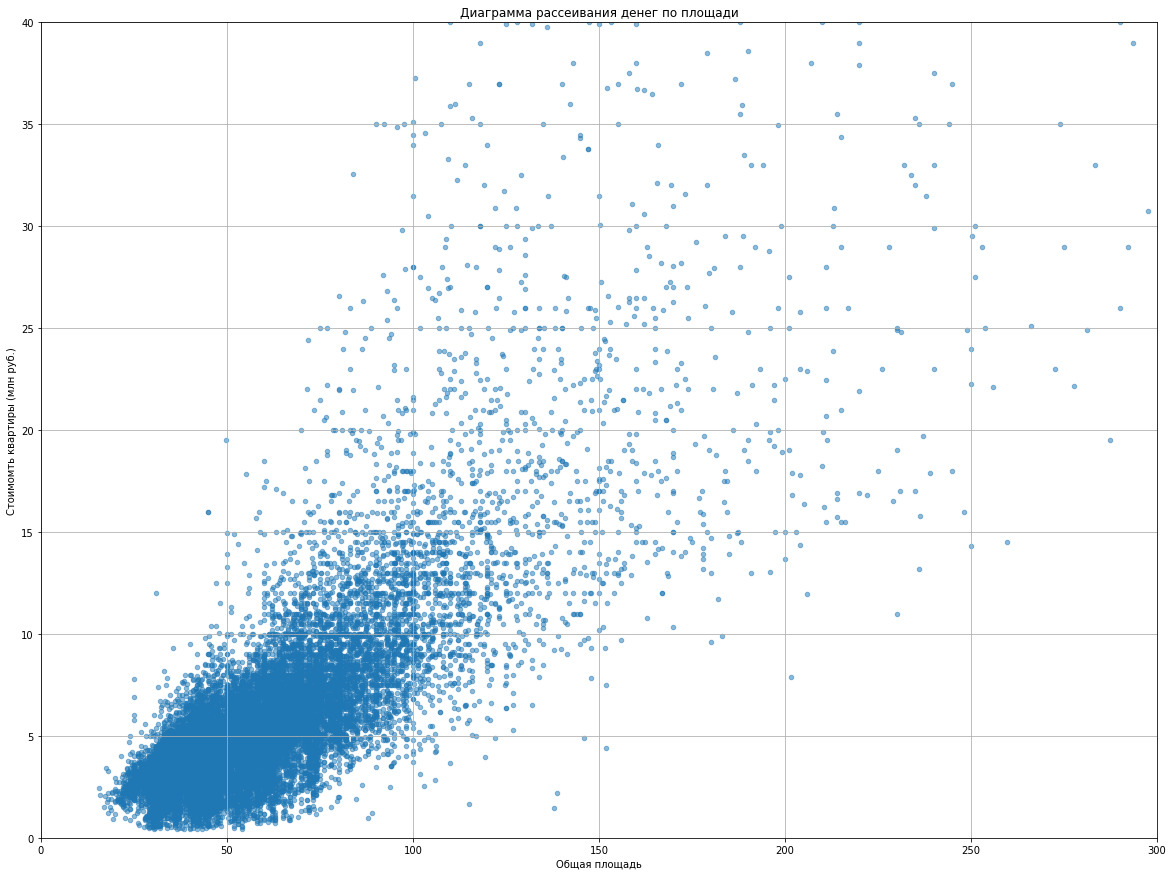

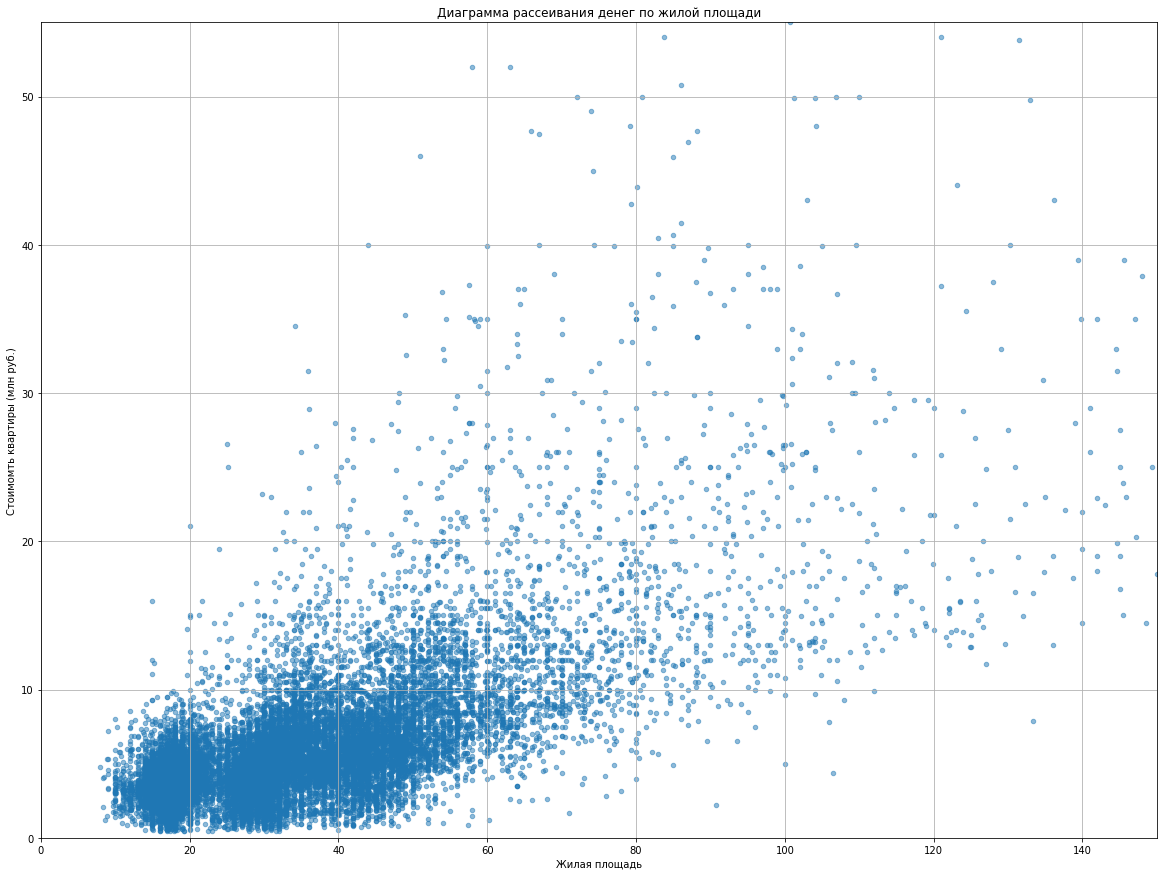

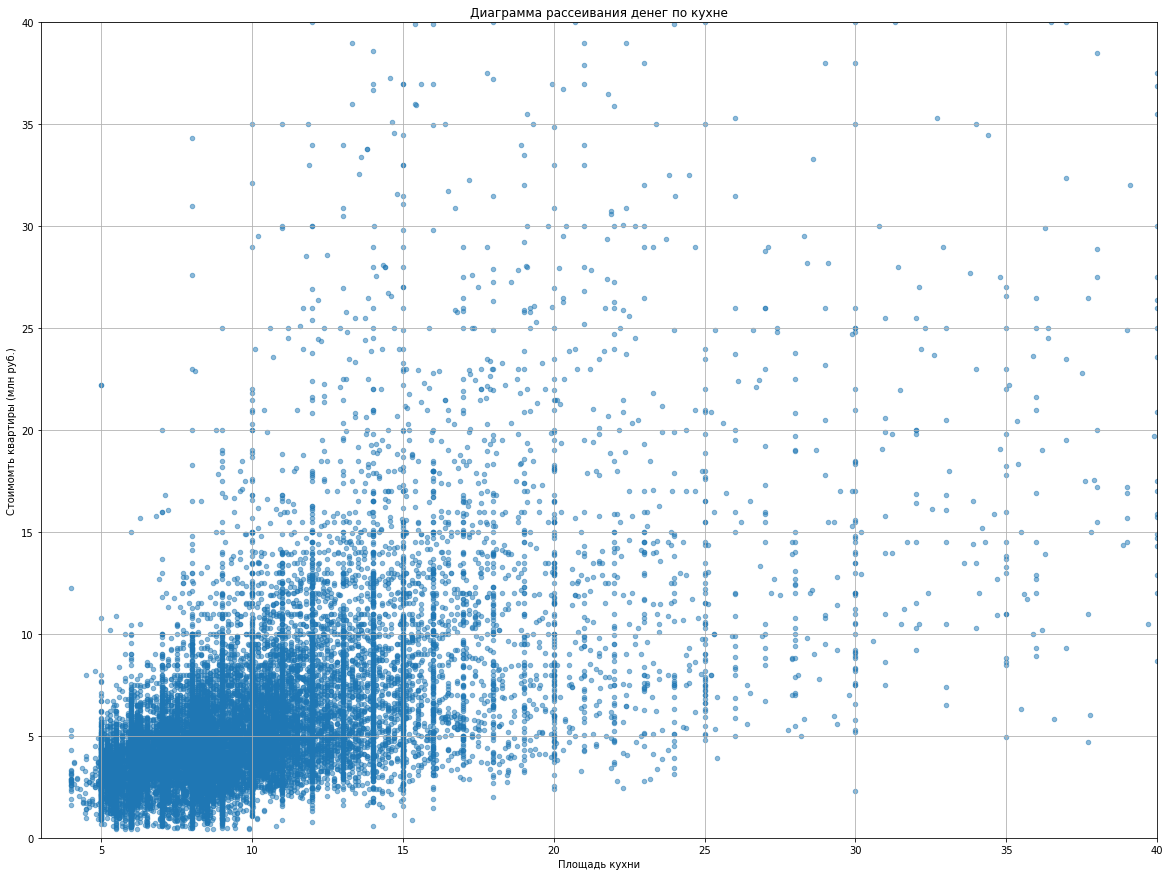

Также существенное положительное влияние на полную стоимость квартиры оказывает количество комнат (коэффициент кореляции 0.52).

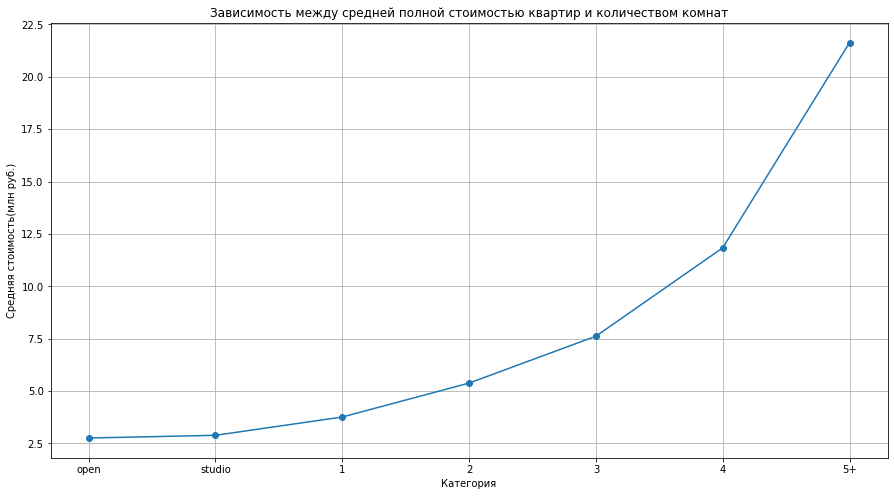

Расположение квартиры в доме влияет на ее полную стоимость. Квартиры, расположенные на первом этаже, в среднем дешевле квартир, рассположенных на последнем этаже, а они в свою очередь в среднем дешевле квартир, расположенных на других этажа. 

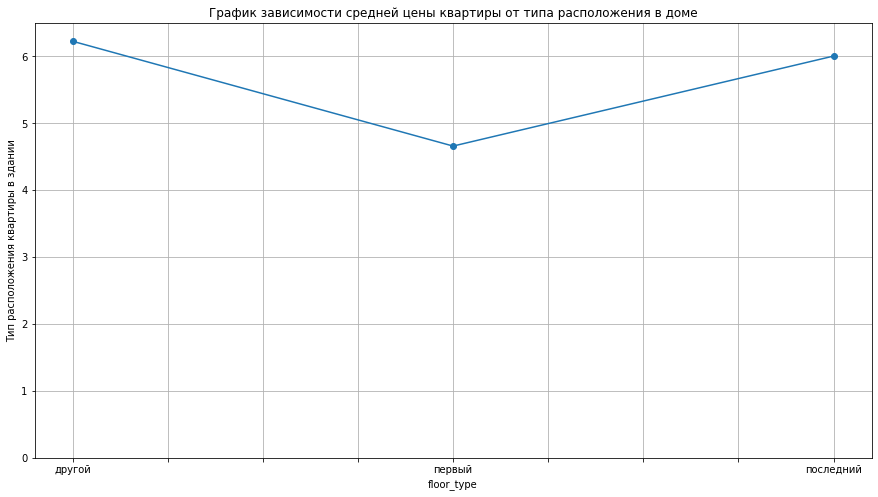

День, месяц и год публикации не оказывают влияния на полную стоимость квартиры (коэффициент корреляции по абсолютному значению не превышает 0.01).

Однако заметно сильное отрицательное влияние количества объявлений в год на среднюю стоимость квартиры, коэффициент корреляции -0.87(2014 и 2019 года неполные, поэтому не включены). То есть чем больше предложение на рынке недвижимости, тем меньше полная стоимость квартиры. Самые перенасыщенные года -- 2017 и 2018.

##### Цена квадратного метра в 10 населённых пунктах с наибольшим числом объявлений



Самые широко представленные в выборке населенные пункты:

|Населенный пункт|количество объявлений|средняя цена|медиана|максимальная|минимальная|
|:----|:----|:----|:----|:----|:----|
|Санкт-Петербург|15327|111.79|104.37|400.00|15.86|
|Мурино|585|86.00|86.12|138.58|50.00|
|Кудрово|468|95.18|95.56|142.86|54.16|
|Шушары|433|78.64|76.92|147.83|47.70|
|Всеволожск|394|67.30|65.79|136.42|31.40|
|Пушкин|345|99.90|98.49|150.00|59.84|
|Колпино|337|75.45|74.72|125.00|47.96|
|Парголово|327|90.18|91.64|138.52|39.21|
|Гатчина|306|68.94|67.86|146.32|10.51|
|Выборг|235|58.30|58.31|107.47|18.75|

Все цены указаны в тысячях рублей за 1. кв. м.

Самая высокая цена за 1. кв. м. в Санкт-Петербурге, а самая низкая в Выборге.

##### Влияние расстояния до центра на стоимость квартир в Санкт-Петербурге

В целом, при удалении от центра цена снижается, но есть отклонения, свидетельствующие о том, что в некоторых районах на расстоянии 4-7 км недвижимость дороже чем в более близких к центру.

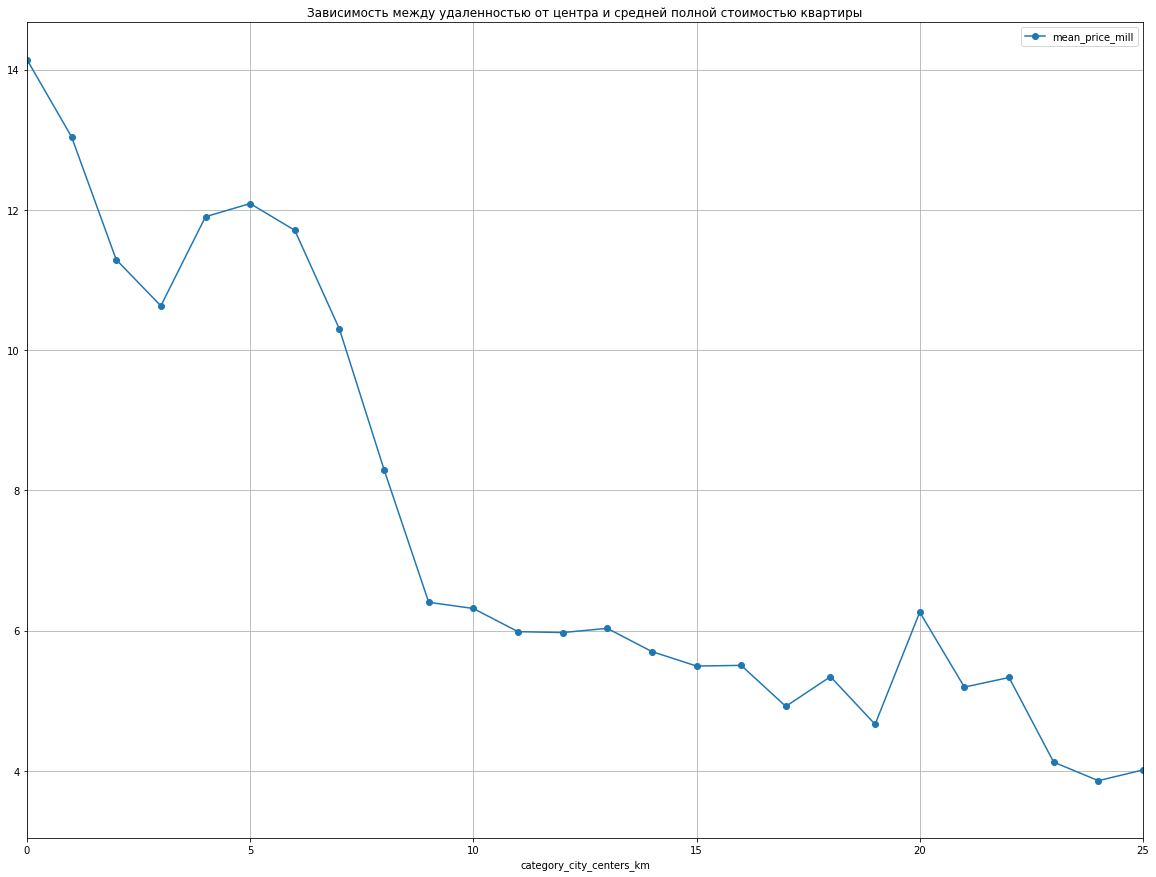

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.